<a href="https://colab.research.google.com/github/ericyoc/the_applied_ai_universe_coding_guide/blob/main/Applied_AI_Universe_Coding_Guide_Hybrid_Quantum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Quantum & Hybrid AI Universe Coding
### IBM Qiskit · Google Cirq · PennyLane

This notebook extends *The AI Universe* into two new inner rings:
**Hybrid Quantum-Classical AI** and **Quantum AI**.

| Module | Ring | Key Topics |
|--------|------|------------|
| 0 | Setup | Drive, libraries, Quantum Universe diagram |
| 7 | Hybrid Quantum-Classical | QAOA, Quantum Kernels, VQC, Hybrid QNN, QGAN |
| 8 | Quantum AI | Bell States, Grover, VQE, Cirq Teleportation, Feature Maps |
| 9 | Summary | All 9 demos, comparison table |

> **All demos use simulators** — no real quantum hardware required.  
> **GPU Runtime recommended:** *Runtime → Change runtime type → T4 GPU*  
> **Run top-to-bottom.** Each module is self-contained.


---
## Module 0 — Setup & Environment
### 0.1 Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os
SAVE_DIR = '/content/drive/MyDrive/AI_Universe_Quantum'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"✅ Drive mounted. Outputs → {SAVE_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted. Outputs → /content/drive/MyDrive/AI_Universe_Quantum


### 0.2 Install Quantum Libraries

In [ ]:
import subprocess, sys

print("Installing quantum packages...\n")

# Uninstall anything conflicting
subprocess.run([sys.executable, "-m", "pip", "uninstall", "-q", "-y",
                "pennylane", "pennylane-qiskit", "PennyLane", "cirq-core", "cirq"],
               capture_output=True)

packages = [
    ("attrs>=22.2.0",  "attrs        (cirq fix)"),
    ("pennylane",      "PennyLane"),
    ("qiskit==1.2.4",  "Qiskit"),
    ("qiskit-aer",     "Qiskit Aer"),
    ("cirq==1.3.0", "Google Cirq"),
    ("torch",          "PyTorch"),
    ("networkx",       "NetworkX"),
]

for pkg, label in packages:
    r = subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", pkg],
        capture_output=True, text=True)
    print(f"  {'✅' if r.returncode == 0 else '❌  ERROR:'} {label}")
    if r.returncode != 0:
        print(f"     {r.stderr.strip()[:120]}")

print("\n⚠️  Runtime → Restart session → Run all cells from top.")

Installing quantum packages...

  ✅ attrs        (cirq fix)
  ✅ PennyLane
  ✅ Qiskit
  ✅ Qiskit Aer
  ✅ Google Cirq
  ✅ PyTorch
  ✅ NetworkX

⚠️  Runtime → Restart session → Run all cells from top.


### 0.3 Standard Imports

In [ ]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "numpy==1.26.4", "pandas", "scikit-learn"],
               capture_output=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings, math, time
import seaborn as sns
warnings.filterwarnings("ignore")
np.random.seed(42)

import pennylane as qml
from pennylane import numpy as pnp
import torch
import torch.nn as nn
import networkx as nx
from qiskit_aer import AerSimulator
from sklearn.decomposition import PCA
from sklearn.datasets import (load_iris, make_moons, make_classification)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from qiskit import QuantumCircuit, transpile, QuantumRegister, ClassicalRegister

print("✅ All imports successful")

# ── Global B&W / white-bg / 6x9 book settings ────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'savefig.facecolor': 'white',
    'text.color':        'black',
    'axes.labelcolor':   'black',
    'xtick.color':       'black',
    'ytick.color':       'black',
    'axes.edgecolor':    'black',
    'grid.color':        '0.85',
    'font.size':         10,
    'axes.titlesize':    12,
    'axes.labelsize':    10,
})
plt.style.use('grayscale')
sns.set_style('white')
print("✅ Plot settings applied")

✅ All imports successful
✅ Plot settings applied


### 0.4 Quantum AI Universe — Extended Rings Diagram

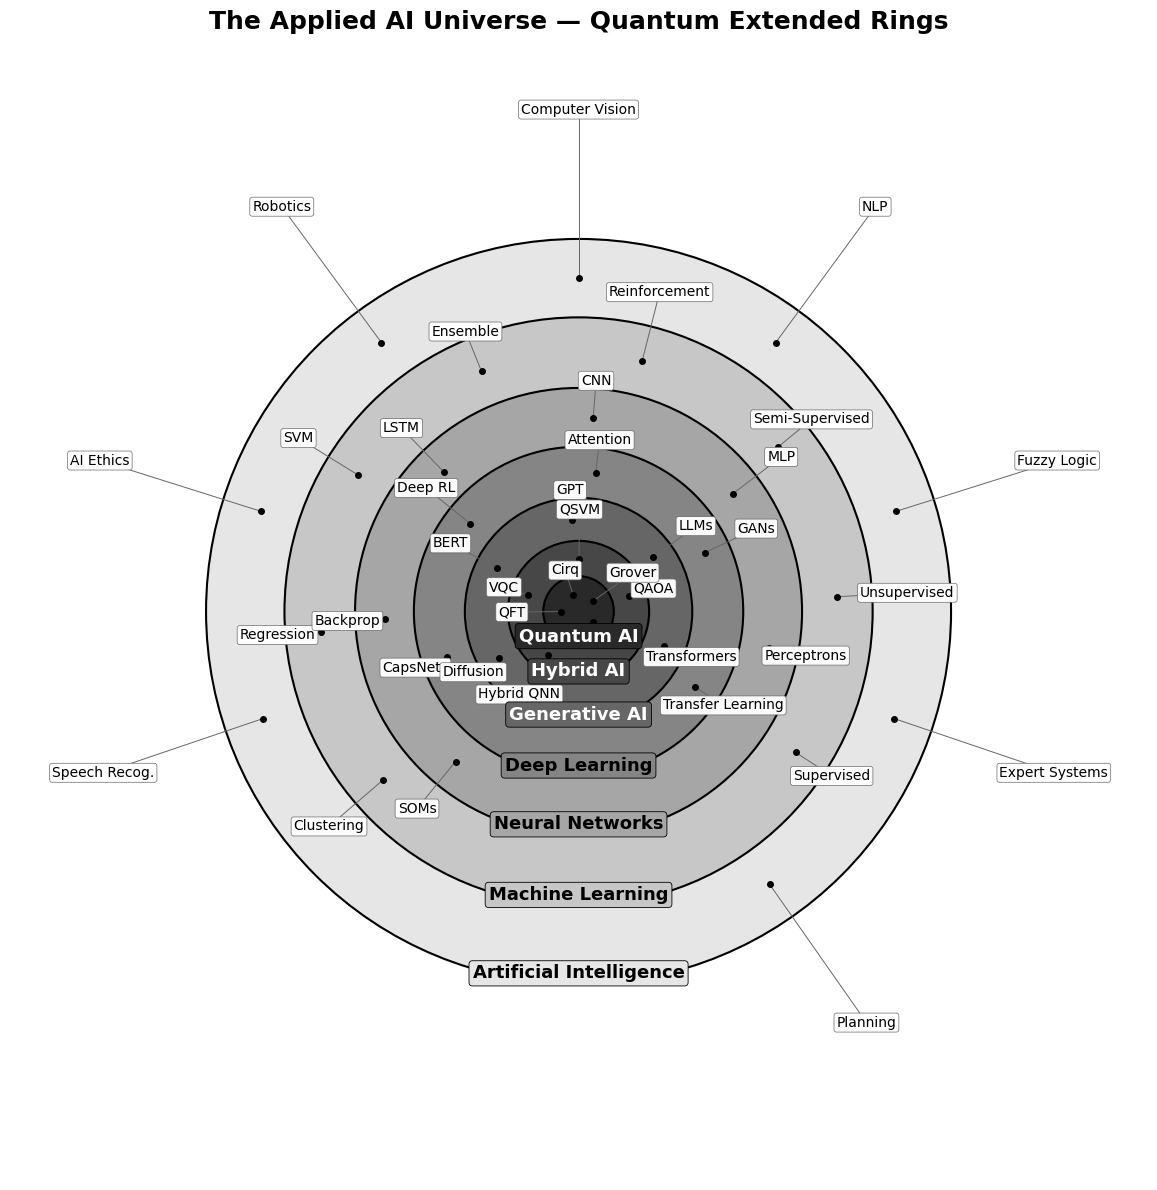

✅ Quantum Universe diagram saved.


In [ ]:
fig, ax = plt.subplots(figsize=(12, 12))
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
ax.set_xlim(-1.45, 1.45); ax.set_ylim(-1.45, 1.45)
ax.set_aspect('equal'); ax.axis('off')

LABEL_FS = 10

rings = [
    (0.95, 0.75, '0.90', 'Artificial Intelligence',
     ['Planning','Expert Systems','Fuzzy Logic','NLP',
      'Computer Vision','Robotics','AI Ethics','Speech Recog.']),
    (0.75, 0.57, '0.78', 'Machine Learning',
     ['Supervised','Unsupervised','Semi-Supervised','Reinforcement',
      'Ensemble','SVM','Regression','Clustering']),
    (0.57, 0.42, '0.65', 'Neural Networks',
     ['Perceptrons','MLP','CNN','LSTM','Backprop','SOMs']),
    (0.42, 0.29, '0.52', 'Deep Learning',
     ['Transfer Learning','GANs','Attention','Deep RL','CapsNets']),
    (0.29, 0.18, '0.40', 'Generative AI',
     ['Transformers','LLMs','GPT','BERT','Diffusion']),
    (0.18, 0.09, '0.28', 'Hybrid AI',
     ['QAOA','QSVM','VQC','Hybrid QNN']),
    (0.09, 0.00, '0.16', 'Quantum AI',
     ['VQE','Grover','Cirq','QFT']),
]

label_r_map = {
    0.95: 1.28,
    0.75: (0.77, 0.84),
    0.57: (0.59, 0.65),
    0.42: (0.44, 0.50),
    0.29: (0.31, 0.37),
    0.18: (0.20, 0.26),
    0.09: (0.11, 0.17),
}
ring_offsets = {
    0.95: math.radians(0),
    0.75: math.radians(22),
    0.57: math.radians(44),
    0.42: math.radians(22),
    0.29: math.radians(33),
    0.18: math.radians(72),
    0.09: math.radians(18),
}

for outer_r, inner_r, facecolor, ring_label, topics in rings:
    ax.add_patch(plt.Circle((0, 0), outer_r, color=facecolor, zorder=1))
    ax.add_patch(plt.Circle((0, 0), outer_r, color='black',
                             fill=False, lw=1.5, zorder=2))

    gray_val  = float(facecolor)
    txt_color = 'white' if gray_val < 0.5 else 'black'

    ax.text(0, -(outer_r - 0.05), ring_label,
            ha='center', va='top', fontsize=13, fontweight='bold',
            color=txt_color, zorder=10,
            bbox=dict(boxstyle='round,pad=0.2', fc=facecolor,
                      ec='black', lw=0.6, alpha=1.0))

    n       = len(topics)
    dot_r   = (outer_r + inner_r) / 2
    offset  = ring_offsets[outer_r]
    GAP     = math.radians(35)
    a_start = -math.pi / 2 + GAP + offset
    a_step  = (2 * math.pi - 2 * GAP) / n

    lbl = label_r_map[outer_r]

    for i, topic in enumerate(topics):
        angle = a_start + a_step * i
        dx = dot_r * math.cos(angle)
        dy = dot_r * math.sin(angle)
        ax.plot(dx, dy, 'o', color='black', ms=4, zorder=8)

        r_a, r_b = (lbl, lbl) if isinstance(lbl, float) else lbl
        lbl_r = r_a if i % 2 == 0 else r_b

        lx = lbl_r * math.cos(angle)
        ly = lbl_r * math.sin(angle)
        ax.plot([dx, lx], [dy, ly], color='0.4', lw=0.7, zorder=4)
        ax.text(lx, ly, topic, ha='center', va='center',
                fontsize=LABEL_FS, color='black', zorder=9,
                bbox=dict(boxstyle='round,pad=0.18', fc='white',
                          ec='0.4', lw=0.5, alpha=0.97))

ax.set_title('The Applied AI Universe — Quantum Extended Rings',
             color='black', fontsize=18, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/00_quantum_universe_diagram.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Quantum Universe diagram saved.")

---
## Module 7 — Hybrid Quantum-Classical AI

The **Hybrid Quantum-Classical** ring sits just inside Generative AI.
These methods are practical *today* on NISQ (Noisy Intermediate-Scale Quantum) hardware.

| Demo | Method | Library | Key Idea |
|------|--------|---------|----------|
| 7.1 | QAOA Max-Cut | PennyLane | Quantum optimization of combinatorial problems |
| 7.2 | Quantum Kernel SVM | PennyLane + sklearn | Classical SVM with quantum feature map kernel |
| 7.3 | Variational Quantum Classifier | PennyLane | Trainable quantum circuit as classifier |
| 7.4 | Hybrid QNN | PennyLane + PyTorch | Classical NN layers + quantum layer |
| 7.5 | Quantum GAN | PennyLane | Quantum generator + classical discriminator |


### 7.1 QAOA — Quantum Approximate Optimization Algorithm

**Problem:** Max-Cut on a 4-node graph — partition nodes into two groups
maximising the number of edges crossing the cut.

**Hybrid loop:** Quantum circuit (parameterised) → measure expectation value →
classical optimizer (Adam) updates parameters → repeat.

> Library: **PennyLane** · Simulator: `default.qubit`


  Step   0  Cost = -0.1529
  Step  20  Cost = -2.3368
  Step  40  Cost = -2.4499
  Step  60  Cost = -2.4604


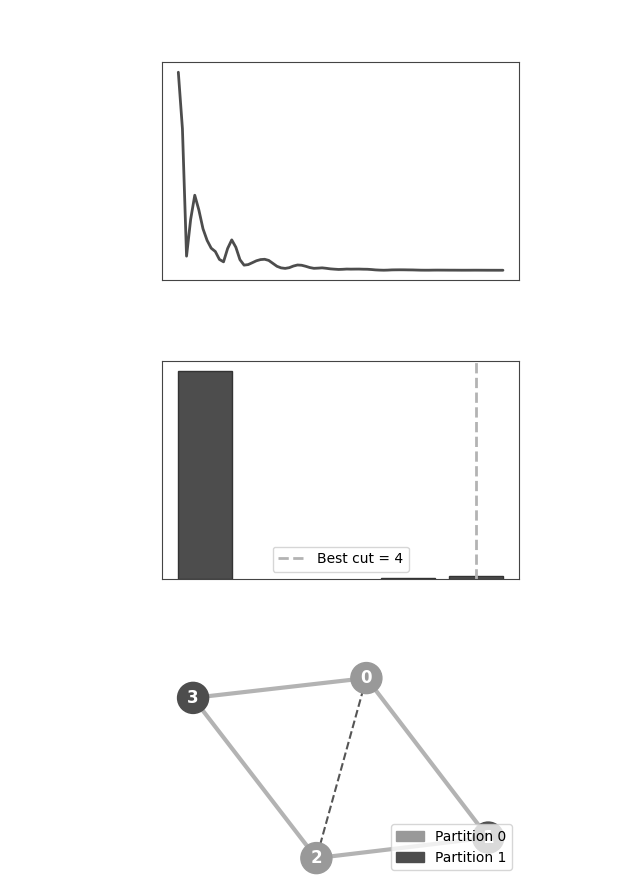

          Metric Value
        n_qubits     4
     QAOA layers     3
       Optimiser  Adam
           Steps    80
  Best cut found     4
Max possible cut     5

✅ QAOA demo complete.


In [ ]:
import pennylane as qml
from pennylane import numpy as pnp
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# ── Graph definition ──────────────────────────────────────────────────────────
edges = [(0, 1), (1, 2), (2, 3), (3, 0), (0, 2)]
n_nodes = 4
G = nx.Graph()
G.add_nodes_from(range(n_nodes))
G.add_edges_from(edges)

# ── PennyLane device (simulator) ─────────────────────────────────────────────
n_qubits = n_nodes
dev = qml.device("default.qubit", wires=n_qubits)

# ── Cost Hamiltonian: H = -½ Σ(1 - Z_i Z_j) for each edge ───────────────────
coeffs = [-0.5] * len(edges)
obs    = [qml.PauliZ(i) @ qml.PauliZ(j) for i, j in edges]
H_cost = qml.Hamiltonian(coeffs, obs)

# ── QAOA circuit ──────────────────────────────────────────────────────────────
@qml.qnode(dev)
def qaoa_circuit(params):
    gammas = params[0]   # cost layer angles
    betas  = params[1]   # mixer layer angles
    n_layers = len(gammas)

    # Initial equal superposition
    for i in range(n_qubits):
        qml.Hadamard(wires=i)

    for layer in range(n_layers):
        # Cost unitary: exp(-i γ H_cost)
        for i, j in edges:
            qml.CNOT(wires=[i, j])
            qml.RZ(2 * gammas[layer], wires=j)
            qml.CNOT(wires=[i, j])
        # Mixer unitary: exp(-i β H_mixer)
        for k in range(n_qubits):
            qml.RX(2 * betas[layer], wires=k)

    return qml.expval(H_cost)

# ── Optimise ──────────────────────────────────────────────────────────────────
n_layers = 3
params = pnp.array(
    [[0.5] * n_layers, [0.5] * n_layers],
    requires_grad=True
)

opt  = qml.AdamOptimizer(stepsize=0.15)
loss_history = []
for step in range(80):
    params, cost = opt.step_and_cost(qaoa_circuit, params)
    loss_history.append(float(cost))
    if step % 20 == 0:
        print(f"  Step {step:3d}  Cost = {cost:.4f}")

# ── Sample final state ────────────────────────────────────────────────────────
# ── Sample final state using probabilities (no shots needed) ──────────────────
@qml.qnode(dev)
def prob_circuit(params):
    n_l = params.shape[1]
    for i in range(n_qubits):
        qml.Hadamard(wires=i)
    for layer in range(n_l):
        for i, j in edges:
            qml.CNOT(wires=[i, j])
            qml.RZ(2 * params[0][layer], wires=j)
            qml.CNOT(wires=[i, j])
        for k in range(n_qubits):
            qml.RX(2 * params[1][layer], wires=k)
    return qml.probs(wires=range(n_qubits))

probs = np.array(prob_circuit(params))
# Sample 200 bitstrings from the probability distribution classically
n_states = 2 ** n_qubits
state_indices = np.random.choice(n_states, size=200, p=probs)
samples = np.array([[int(b) for b in format(idx, f'0{n_qubits}b')]
                    for idx in state_indices])

cut_values = []
for s in samples:
    cut = sum(1 for i, j in edges if s[i] != s[j])
    cut_values.append(cut)
best_cut = max(cut_values)
best_sample = samples[np.argmax(cut_values)]

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(4.5, 9.0))
axes = axes.flatten()
fig.patch.set_facecolor('white')

# Loss curve
ax = axes[0]
ax.set_facecolor('white')
ax.plot(loss_history, color='0.3', lw=2)
ax.set_title('QAOA Training Loss', color='white', fontweight='bold')
ax.set_xlabel('Optimisation Step', color='white')
ax.set_ylabel('Cost (Max-Cut Expectation)', color='white')
ax.tick_params(colors='white'); ax.spines[:].set_color('#444')

# Cut distribution
ax = axes[1]
ax.set_facecolor('white')
unique, cnts = np.unique(cut_values, return_counts=True)
ax.bar(unique, cnts / cnts.sum(), color='0.3', edgecolor='0.2')
ax.axvline(best_cut, color='0.7', lw=2, linestyle='--', label=f'Best cut = {best_cut}')
ax.set_title('Sampled Cut Distribution', color='white', fontweight='bold')
ax.set_xlabel('Cut Value', color='white')
ax.set_ylabel('Probability', color='white')
ax.legend(facecolor='white', labelcolor='black')
ax.tick_params(colors='white'); ax.spines[:].set_color('#444')

# Graph partition
ax = axes[2]
ax.set_facecolor('white')
partition = {i: int(best_sample[i]) for i in range(n_nodes)}
colors = ['0.6' if partition[n] == 0 else '0.3' for n in G.nodes()]
pos = nx.spring_layout(G, seed=42)
cut_edges    = [(i, j) for i, j in edges if partition[i] != partition[j]]
non_cut_edges = [(i, j) for i, j in edges if partition[i] == partition[j]]
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colors, node_size=500)
nx.draw_networkx_labels(G, pos, ax=ax, font_color='white', font_weight='bold')
nx.draw_networkx_edges(G, pos, edgelist=cut_edges, ax=ax,
                       edge_color='0.7', width=3, label='Cut edges')
nx.draw_networkx_edges(G, pos, edgelist=non_cut_edges, ax=ax,
                       edge_color='#555', width=1.5, style='dashed')
p0 = mpatches.Patch(color='0.6', label='Partition 0')
p1 = mpatches.Patch(color='0.3', label='Partition 1')
ax.legend(handles=[p0, p1], facecolor='white', labelcolor='black', loc='lower right')
ax.set_title(f'Best Max-Cut = {best_cut} / {len(edges)}', color='white', fontweight='bold')
ax.axis('off')

plt.suptitle('7.1 QAOA — Quantum Approximate Optimization (Max-Cut)',
             color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/07_1_qaoa_maxcut.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

df = pd.DataFrame({'Metric': ['n_qubits', 'QAOA layers', 'Optimiser',
                               'Steps', 'Best cut found', 'Max possible cut'],
                   'Value': [n_qubits, n_layers, 'Adam', 80, best_cut, len(edges)]})
print(df.to_string(index=False))
print("\n✅ QAOA demo complete.")

### 7.2 Quantum Kernel SVM (QSVM)

A classical SVM uses a **kernel function** $k(x_1, x_2)$ to measure similarity
between points in a high-dimensional feature space.
A **quantum kernel** computes that similarity using quantum interference:
encode both points into quantum states, then measure the overlap $|\langle \phi(x_1) | \phi(x_2) \rangle|^2$.

> Library: **PennyLane** + **scikit-learn** · Dataset: `make_moons`


Computing quantum kernel matrices...
  Kernel computation: 12.8s
  Quantum SVM accuracy : 0.688
  Classical SVM accuracy: 1.000


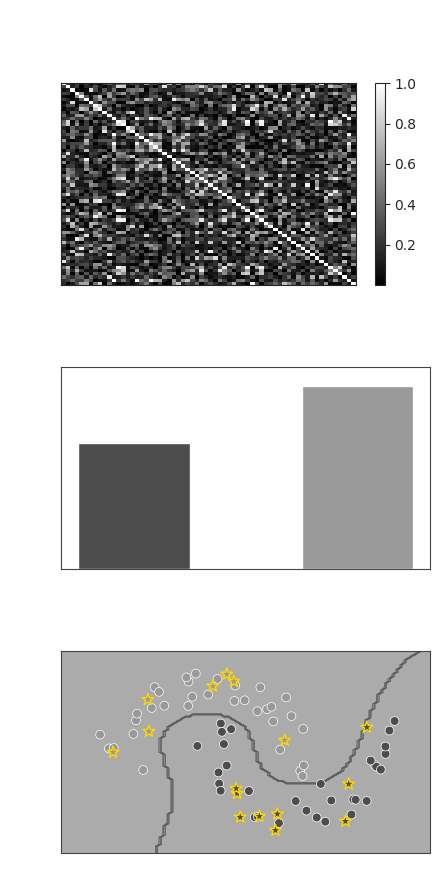


✅ QSVM demo complete.


In [ ]:
import pennylane as qml
from pennylane import numpy as pnp
import numpy as np
from sklearn.svm import SVC
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# ── Data ──────────────────────────────────────────────────────────────────────
np.random.seed(42)
X, y = make_moons(n_samples=80, noise=0.12, random_state=42)
X = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# ── Quantum kernel circuit ────────────────────────────────────────────────────
n_qubits = 2
dev_kernel = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev_kernel)
def kernel_circuit(x1, x2):
    """Compute <phi(x1)|phi(x2)> via quantum feature map."""
    # Encode x1
    for i in range(n_qubits):
        qml.Hadamard(wires=i)
        qml.RZ(2.0 * x1[i], wires=i)
    qml.CNOT(wires=[0, 1])
    qml.RZ(2.0 * (np.pi - x1[0]) * (np.pi - x1[1]), wires=1)
    qml.CNOT(wires=[0, 1])
    # Inverse encode x2 (Hermitian adjoint)
    qml.adjoint(qml.CNOT)(wires=[0, 1])
    qml.RZ(-2.0 * (np.pi - x2[0]) * (np.pi - x2[1]), wires=1)
    qml.adjoint(qml.CNOT)(wires=[0, 1])
    for i in range(n_qubits):
        qml.RZ(-2.0 * x2[i], wires=i)
        qml.Hadamard(wires=i)
    return qml.probs(wires=range(n_qubits))

def quantum_kernel(A, B):
    """Gram matrix: K[i,j] = |<phi(A_i)|phi(B_j)>|^2"""
    K = np.zeros((len(A), len(B)))
    for i, a in enumerate(A):
        for j, b in enumerate(B):
            K[i, j] = float(kernel_circuit(a, b)[0])  # |00> overlap
    return K

print("Computing quantum kernel matrices...")
t0 = time.time()
K_train = quantum_kernel(X_train, X_train)
K_test  = quantum_kernel(X_test,  X_train)
print(f"  Kernel computation: {time.time()-t0:.1f}s")

# ── Quantum SVM ───────────────────────────────────────────────────────────────
qsvm = SVC(kernel='precomputed', C=5.0)
qsvm.fit(K_train, y_train)
y_pred_q = qsvm.predict(K_test)
qsvm_acc = accuracy_score(y_test, y_pred_q)

# ── Classical RBF SVM baseline ────────────────────────────────────────────────
csvm = SVC(kernel='rbf', gamma='scale', C=5.0)
csvm.fit(X_train, y_train)
y_pred_c = csvm.predict(X_test)
csvm_acc = accuracy_score(y_test, y_pred_c)

print(f"  Quantum SVM accuracy : {qsvm_acc:.3f}")
print(f"  Classical SVM accuracy: {csvm_acc:.3f}")

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(4.5, 9.0))
axes = axes.flatten()
fig.patch.set_facecolor('white')
cmap_pts = ListedColormap(['0.6', '0.3'])
cmap_bg  = ListedColormap(['0.35', '0.35'])

# Kernel matrix heatmap
ax = axes[0]
ax.set_facecolor('white')
im = ax.imshow(K_train, cmap='gray', aspect='auto')
plt.colorbar(im, ax=ax)
ax.set_title('Quantum Kernel Matrix\n(Training Set)', color='white', fontweight='bold')
ax.tick_params(colors='white')

# Comparison bar chart
ax = axes[1]
ax.set_facecolor('white')
bars = ax.bar(['Quantum SVM', 'Classical SVM'], [qsvm_acc, csvm_acc],
               color=['0.3', '0.6'], edgecolor='white', width=0.5)
for bar, val in zip(bars, [qsvm_acc, csvm_acc]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', color='white', fontweight='bold')
ax.set_ylim(0, 1.1)
ax.set_title('QSVM vs Classical SVM', color='white', fontweight='bold')
ax.set_ylabel('Test Accuracy', color='white')
ax.tick_params(colors='white'); ax.spines[:].set_color('#444')

# Decision boundary (classical kernel for fast grid prediction)
ax = axes[2]
ax.set_facecolor('white')
h = 0.05
xx, yy = np.meshgrid(np.arange(X[:, 0].min()-0.5, X[:, 0].max()+0.5, h),
                     np.arange(X[:, 1].min()-0.5, X[:, 1].max()+0.5, h))
Z = csvm.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
ax.contourf(xx, yy, Z, alpha=0.5, cmap=cmap_bg)
ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cmap_pts, s=40, edgecolors='white', lw=0.5)
ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=cmap_pts, s=80, marker='*', edgecolors='gold', lw=1)
ax.set_title(f'Classical SVM boundary\n(Test acc={csvm_acc:.3f})', color='white', fontweight='bold')
ax.tick_params(colors='white'); ax.spines[:].set_color('#444')

plt.suptitle('7.2 Quantum Kernel SVM (QSVM)', color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/07_2_quantum_kernel_svm.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()
print("\n✅ QSVM demo complete.")

### 7.3 Variational Quantum Classifier (VQC)

A VQC is a parameterised quantum circuit trained end-to-end with gradient descent.
It plays the same role as a classical neural network — but runs on quantum hardware.

**Structure:**
1. **Data encoding** — classical features → qubit rotations
2. **Variational layers** — trainable gates entangle qubits
3. **Measurement** — expectation values → class prediction

> Library: **PennyLane** · Dataset: Iris (binary)


Training VQC...
  Step   0  Loss=0.9497  Test Acc=0.605
  Step  10  Loss=0.8721  Test Acc=0.947
  Step  20  Loss=0.8305  Test Acc=0.737
  Step  30  Loss=0.7943  Test Acc=0.789


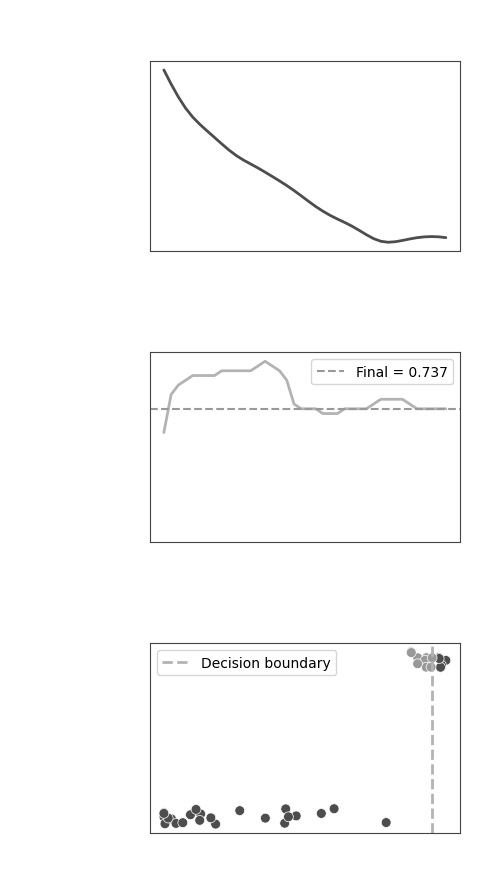


✅ VQC demo complete. Final test accuracy: 0.737


In [ ]:
import pennylane as qml
import torch
import torch.nn as nn
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

iris = load_iris()
X, y = iris.data, (iris.target == 0).astype(int)
X = StandardScaler().fit_transform(X)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42)
X_tr, y_tr = X_tr[:60], y_tr[:60]

X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
X_te_t = torch.tensor(X_te, dtype=torch.float32)
y_tr_t = torch.tensor(y_tr, dtype=torch.float32)

n_qubits, n_layers = 4, 2
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def vqc_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(n_qubits), rotation='Y')
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return qml.expval(qml.PauliZ(0))

weight_shape = {"weights": qml.StronglyEntanglingLayers.shape(n_layers=n_layers, n_wires=n_qubits)}
model   = nn.Sequential(qml.qnn.TorchLayer(vqc_circuit, weight_shape), nn.Sigmoid())
opt     = torch.optim.Adam(model.parameters(), lr=0.08)
loss_fn = nn.BCELoss()

loss_history, acc_history = [], []
print("Training VQC...")
for step in range(40):
    model.train()
    opt.zero_grad()
    out  = (model(X_tr_t).squeeze() + 1) / 2
    loss = loss_fn(out, y_tr_t)
    loss.backward()
    opt.step()
    model.eval()
    with torch.no_grad():
        raw = model(X_te_t).squeeze().numpy()
        acc = accuracy_score(y_te, (raw >= 0.5).astype(int))
    loss_history.append(loss.item())
    acc_history.append(acc)
    if step % 10 == 0:
        print(f"  Step {step:3d}  Loss={loss.item():.4f}  Test Acc={acc:.3f}")

final_acc = acc_history[-1]

fig, axes = plt.subplots(3, 1, figsize=(4.5, 9.0))
axes = axes.flatten()
fig.patch.set_facecolor('white')

ax = axes[0]
ax.set_facecolor('white')
ax.plot(loss_history, color='0.3', lw=2)
ax.set_title('VQC Training Loss', color='white', fontweight='bold')
ax.set_xlabel('Epoch', color='white'); ax.set_ylabel('BCE Loss', color='white')
ax.tick_params(colors='white'); ax.spines[:].set_color('#444')

ax = axes[1]
ax.set_facecolor('white')
ax.plot(acc_history, color='0.7', lw=2)
ax.axhline(final_acc, color='0.6', lw=1.5, linestyle='--', label=f'Final = {final_acc:.3f}')
ax.set_title('VQC Test Accuracy', color='white', fontweight='bold')
ax.set_xlabel('Epoch', color='white'); ax.set_ylabel('Accuracy', color='white')
ax.set_ylim(0, 1.05)
ax.tick_params(colors='white'); ax.spines[:].set_color('#444')
ax.legend(facecolor='white', labelcolor='black')

ax = axes[2]
ax.set_facecolor('white')
model.eval()
with torch.no_grad():
    raw = model(X_te_t).squeeze().numpy()
correct     = (raw >= 0.5).astype(int) == y_te
colors_pts  = ['0.3' if c else '0.6' for c in correct]
ax.scatter(raw, y_te + np.random.uniform(-0.05, 0.05, len(y_te)),
           c=colors_pts, s=50, edgecolors='white', lw=0.5)
ax.axvline(0.5, color='0.7', lw=2, linestyle='--', label='Decision boundary')
ax.set_title(f'Prediction Scores\nTest Acc = {final_acc:.3f}', color='white', fontweight='bold')
ax.set_xlabel('Circuit Output', color='white')
ax.set_ylabel('True Label', color='white')
ax.set_yticks([0, 1]); ax.set_yticklabels(['Non-Setosa', 'Setosa'], color='white')
ax.tick_params(colors='white'); ax.spines[:].set_color('#444')
ax.legend(facecolor='white', labelcolor='black')

plt.suptitle('7.3 Variational Quantum Classifier (VQC) on Iris',
             color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/07_3_vqc_classifier.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()
print(f"\n✅ VQC demo complete. Final test accuracy: {final_acc:.3f}")

### 7.4 Hybrid Quantum-Classical Neural Network

A **Hybrid QNN** sandwiches a quantum circuit between two classical layers:

```
Input → Classical Linear → Quantum Layer → Classical Linear → Output
```

The quantum layer uses `qml.qnn.TorchLayer` which makes it a standard
PyTorch `nn.Module` with trainable quantum parameters.

> Library: **PennyLane + PyTorch** · Dataset: binary classification


Training Hybrid QNN...
Training Classical NN baseline...
  Hybrid QNN  final accuracy: 0.775
  Classical NN final accuracy: 0.800


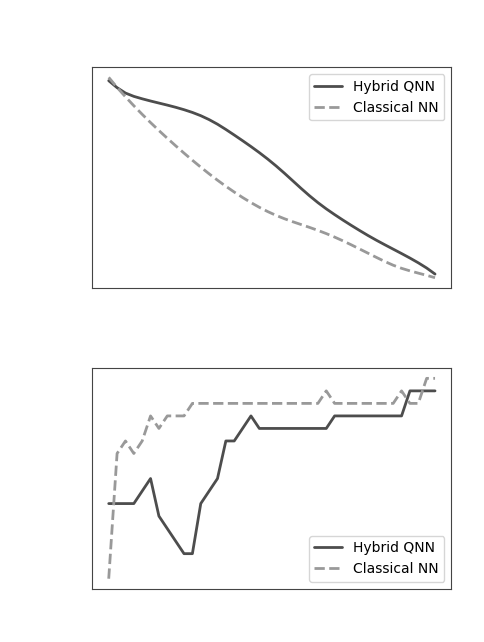


✅ Hybrid QNN demo complete.


In [ ]:
import pennylane as qml
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── Dataset ───────────────────────────────────────────────────────────────────
X_raw, y_raw = make_classification(n_samples=200, n_features=8,
                                    n_informative=4, random_state=42)
X_raw = StandardScaler().fit_transform(X_raw)
X_tr, X_te, y_tr, y_te = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42)

X_train_t = torch.tensor(X_tr, dtype=torch.float32)
X_test_t  = torch.tensor(X_te, dtype=torch.float32)
y_train_t = torch.tensor(y_tr, dtype=torch.float32)
y_test_t  = torch.tensor(y_te, dtype=torch.float32)

# ── Quantum layer ─────────────────────────────────────────────────────────────
n_qubits = 4
n_q_layers = 2
dev_hybrid = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev_hybrid, interface="torch")
def quantum_circuit(inputs, weights):
    # Encode 4 classical values as qubit angles
    qml.AngleEmbedding(inputs, wires=range(n_qubits), rotation='Y')
    # Variational entangling layers
    qml.BasicEntanglerLayers(weights, wires=range(n_qubits))
    # Measure each qubit
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

weight_shapes = {"weights": (n_q_layers, n_qubits)}
qlayer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)

# ── Hybrid model ──────────────────────────────────────────────────────────────
class HybridQNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.pre  = nn.Sequential(nn.Linear(8, n_qubits), nn.Tanh())
        self.qnn  = qlayer
        self.post = nn.Sequential(nn.Linear(n_qubits, 8), nn.ReLU(),
                                  nn.Linear(8, 1), nn.Sigmoid())
    def forward(self, x):
        x = self.pre(x)
        x = self.qnn(x)
        return self.post(x).squeeze()

# ── Classical baseline ────────────────────────────────────────────────────────
class ClassicalNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(8, n_qubits), nn.Tanh(),
                                 nn.Linear(n_qubits, n_qubits), nn.Tanh(),
                                 nn.Linear(n_qubits, 1), nn.Sigmoid())
    def forward(self, x):
        return self.net(x).squeeze()

def train_model(model, n_epochs=40, lr=0.02):
    opt = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss()
    losses, accs = [], []
    for epoch in range(n_epochs):
        model.train()
        opt.zero_grad()
        out = model(X_train_t)
        loss = criterion(out, y_train_t)
        loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            pred = (model(X_test_t) > 0.5).float()
            acc = (pred == y_test_t).float().mean().item()
        losses.append(loss.item()); accs.append(acc)
    return losses, accs

print("Training Hybrid QNN...")
h_model = HybridQNN()
h_losses, h_accs = train_model(h_model, n_epochs=40)

print("Training Classical NN baseline...")
c_model = ClassicalNN()
c_losses, c_accs = train_model(c_model, n_epochs=40)

print(f"  Hybrid QNN  final accuracy: {h_accs[-1]:.3f}")
print(f"  Classical NN final accuracy: {c_accs[-1]:.3f}")

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(4.5, 6.5))
axes = axes.flatten()
fig.patch.set_facecolor('white')

for ax, data, title, ylabel in zip(
        axes,
        [(h_losses, c_losses), (h_accs, c_accs)],
        ['Training Loss', 'Test Accuracy'],
        ['BCE Loss', 'Accuracy']):
    ax.set_facecolor('white')
    ax.plot(data[0], color='0.3', lw=2, label='Hybrid QNN')
    ax.plot(data[1], color='0.6', lw=2, linestyle='--', label='Classical NN')
    ax.set_title(title, color='white', fontweight='bold')
    ax.set_xlabel('Epoch', color='white'); ax.set_ylabel(ylabel, color='white')
    ax.tick_params(colors='white'); ax.spines[:].set_color('#444')
    ax.legend(facecolor='white', labelcolor='black')

plt.suptitle('7.4 Hybrid Quantum-Classical Neural Network',
             color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/07_4_hybrid_qnn.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()
print("\n✅ Hybrid QNN demo complete.")

### 7.5 Quantum GAN (QGAN)

A **QGAN** replaces the classical Generator with a parameterised quantum circuit.
The quantum Generator learns to produce samples matching a target distribution
by competing against a classical Discriminator.

- **Generator**: 2-qubit PennyLane circuit with trainable gates
- **Discriminator**: classical 2-layer MLP (PyTorch)
- **Target**: 1D Gaussian distribution $\mathcal{N}(0.5,\ 0.1)$

> Library: **PennyLane + PyTorch**


Training QGAN (100 epochs)...
  Epoch   0  G loss=0.6646  D loss=0.7046
  Epoch  25  G loss=0.8214  D loss=0.7093
  Epoch  50  G loss=0.8411  D loss=0.5617
  Epoch  75  G loss=0.5609  D loss=0.8247


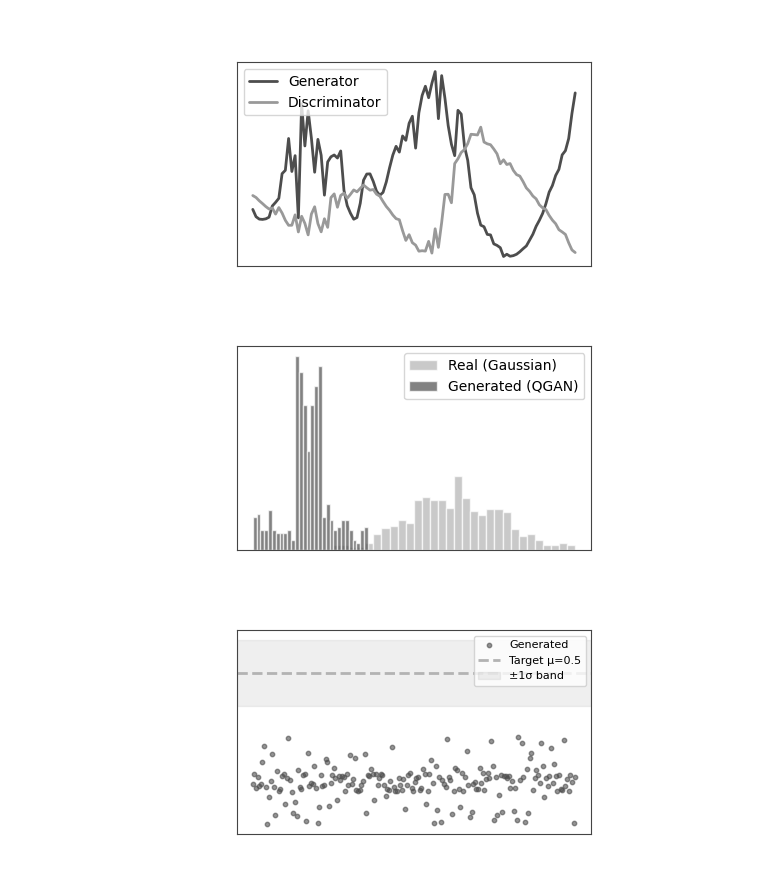


✅ QGAN demo complete.


In [ ]:
import pennylane as qml
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# ── Target distribution ───────────────────────────────────────────────────────
TARGET_MU, TARGET_STD = 0.5, 0.1
def real_samples(n): return torch.tensor(
    np.random.normal(TARGET_MU, TARGET_STD, (n, 1)), dtype=torch.float32)

# ── Quantum generator ─────────────────────────────────────────────────────────
n_qubits_g = 2
dev_g = qml.device("default.qubit", wires=n_qubits_g)

@qml.qnode(dev_g, interface="torch")
def qgan_generator(inputs, weights):
    qml.RY(inputs[0] * np.pi, wires=0)
    qml.RY(inputs[0] * np.pi / 2, wires=1)
    qml.CNOT(wires=[0, 1])
    for layer in range(weights.shape[0]):
        for i in range(n_qubits_g):
            qml.RY(weights[layer, i, 0], wires=i)
            qml.RZ(weights[layer, i, 1], wires=i)
        qml.CNOT(wires=[0, 1])
    return qml.expval(qml.PauliZ(0))

weight_shapes_g = {"weights": (3, n_qubits_g, 2)}
q_gen_layer = qml.qnn.TorchLayer(qgan_generator, weight_shapes_g)

class QuantumGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.qlayer = q_gen_layer
        self.post   = nn.Linear(1, 1)  # Scale output to target range
    def forward(self, noise):
        out = torch.stack([self.qlayer(n.unsqueeze(0)) for n in noise]).squeeze()
        out = out.unsqueeze(1)
        return self.post(out)

# ── Classical discriminator ───────────────────────────────────────────────────
class ClassicalDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(1, 16), nn.LeakyReLU(0.2),
                                 nn.Linear(16, 8),  nn.LeakyReLU(0.2),
                                 nn.Linear(8, 1),   nn.Sigmoid())
    def forward(self, x): return self.net(x)

# ── Training ──────────────────────────────────────────────────────────────────
G = QuantumGenerator(); D = ClassicalDiscriminator()
g_opt = optim.Adam(G.parameters(), lr=0.01)
d_opt = optim.Adam(D.parameters(), lr=0.02)
criterion = nn.BCELoss()

batch = 32
g_losses, d_losses = [], []

print("Training QGAN (100 epochs)...")
for epoch in range(100):
    # -- Discriminator step --
    noise = torch.rand(batch, 1) * 2 - 1
    fake  = G(noise).detach()
    real  = real_samples(batch)
    d_real = criterion(D(real), torch.ones(batch, 1))
    d_fake = criterion(D(fake), torch.zeros(batch, 1))
    d_loss = (d_real + d_fake) / 2
    d_opt.zero_grad(); d_loss.backward(); d_opt.step()

    # -- Generator step --
    noise = torch.rand(batch, 1) * 2 - 1
    fake  = G(noise)
    g_loss = criterion(D(fake), torch.ones(batch, 1))
    g_opt.zero_grad(); g_loss.backward(); g_opt.step()

    g_losses.append(g_loss.item()); d_losses.append(d_loss.item())
    if epoch % 25 == 0:
        print(f"  Epoch {epoch:3d}  G loss={g_loss.item():.4f}  D loss={d_loss.item():.4f}")

# ── Evaluate: compare generated vs real distribution ─────────────────────────
with torch.no_grad():
    noise_eval = torch.rand(500, 1) * 2 - 1
    generated  = G(noise_eval).numpy().flatten()
real_eval = np.random.normal(TARGET_MU, TARGET_STD, 500)

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(4.5, 9.0))
axes = axes.flatten()
fig.patch.set_facecolor('white')

ax = axes[0]
ax.set_facecolor('white')
ax.plot(g_losses, color='0.3', lw=2, label='Generator')
ax.plot(d_losses, color='0.6', lw=2, label='Discriminator')
ax.set_title('QGAN Training Losses', color='white', fontweight='bold')
ax.set_xlabel('Epoch', color='white'); ax.set_ylabel('BCE Loss', color='white')
ax.tick_params(colors='white'); ax.spines[:].set_color('#444')
ax.legend(facecolor='white', labelcolor='black')

ax = axes[1]
ax.set_facecolor('white')
ax.hist(real_eval, bins=30, alpha=0.7, color='0.7', density=True, label='Real (Gaussian)')
ax.hist(generated, bins=30, alpha=0.7, color='0.3', density=True, label='Generated (QGAN)')
ax.set_title('Real vs QGAN Distribution', color='white', fontweight='bold')
ax.set_xlabel('Value', color='white'); ax.set_ylabel('Density', color='white')
ax.tick_params(colors='white'); ax.spines[:].set_color('#444')
ax.legend(facecolor='white', labelcolor='black')

ax = axes[2]
ax.set_facecolor('white')
ax.scatter(range(200), generated[:200], c='0.3', s=10, alpha=0.6, label='Generated')
ax.axhline(TARGET_MU, color='0.7', lw=2, linestyle='--', label=f'Target μ={TARGET_MU}')
ax.axhspan(TARGET_MU - TARGET_STD, TARGET_MU + TARGET_STD,
           alpha=0.2, color='0.7', label=f'±1σ band')
ax.set_title('Generated Sample Scatter', color='white', fontweight='bold')
ax.set_xlabel('Sample index', color='white'); ax.set_ylabel('Generated value', color='white')
ax.tick_params(colors='white'); ax.spines[:].set_color('#444')
ax.legend(facecolor='white', labelcolor='black', fontsize=8)

plt.suptitle('7.5 Quantum GAN (QGAN) — Quantum Generator + Classical Discriminator',
             color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/07_5_qgan.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()
print("\n✅ QGAN demo complete.")

---
## Module 8 — Quantum AI (Qiskit + Cirq)

The **Quantum AI** ring is the innermost layer of our extended universe.
These algorithms go beyond classical limits — but require simulators today.

| Demo | Method | Library | Key Idea |
|------|--------|---------|----------|
| 8.1 | Superposition & Bell States | IBM Qiskit | Quantum fundamentals |
| 8.2 | Grover's Search | IBM Qiskit | Quadratic search speedup |
| 8.3 | VQE | IBM Qiskit | Ground state energy estimation |
| 8.4 | Quantum Teleportation | Google Cirq | Entanglement-based qubit transfer |
| 8.5 | Quantum Feature Maps | PennyLane | Visualise quantum data embedding |


### 8.1 Quantum Fundamentals — Superposition, Entanglement & Bell States

The three pillars of quantum computing:

| Concept | Meaning | Gate |
|---------|---------|------|
| **Superposition** | A qubit is 0 and 1 simultaneously until measured | Hadamard (H) |
| **Entanglement** | Two qubits become correlated — measuring one instantly determines the other | CNOT |
| **Interference** | Probability amplitudes cancel or reinforce to guide computation | Phase gates |

> Library: **IBM Qiskit** · Simulator: `AerSimulator`


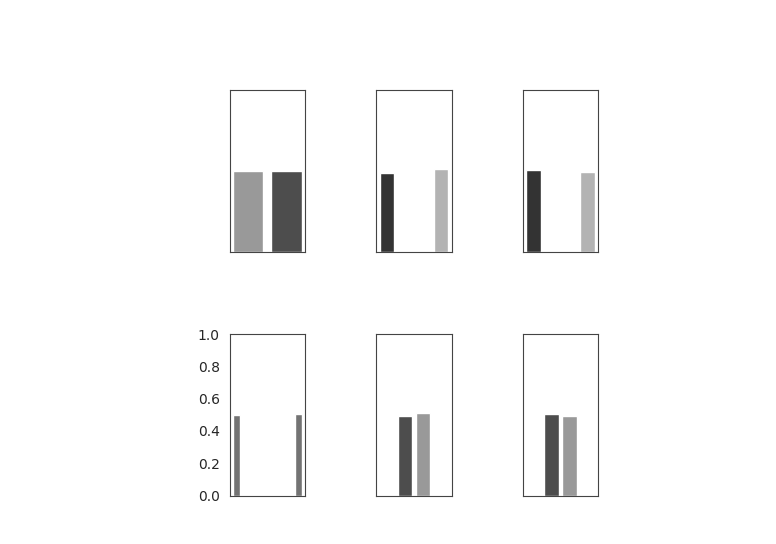

✅ Bell states demo complete.


In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import numpy as np
import matplotlib.pyplot as plt

simulator = AerSimulator()

# ── Demo 1: Single-qubit superposition ───────────────────────────────────────
qc_super = QuantumCircuit(1, 1)
qc_super.h(0)           # H gate: |0> → (|0> + |1>)/√2
qc_super.measure(0, 0)

res_super = simulator.run(transpile(qc_super, simulator), shots=1024).result()
counts_super = res_super.get_counts()

# ── Demo 2: All four Bell states ─────────────────────────────────────────────
def bell_state(phi_plus=True, psi=False, minus=False):
    qc = QuantumCircuit(2, 2)
    if minus: qc.x(0)
    qc.h(0)
    qc.cx(0, 1)
    if psi: qc.x(0)
    qc.measure([0, 1], [0, 1])
    return qc

bell_circuits = {
    'Φ⁺ = (|00⟩+|11⟩)/√2': bell_state(),
    'Φ⁻ = (|00⟩-|11⟩)/√2': bell_state(minus=True),
    'Ψ⁺ = (|01⟩+|10⟩)/√2': bell_state(psi=True),
    'Ψ⁻ = (|01⟩-|10⟩)/√2': bell_state(minus=True, psi=True),
}

bell_counts = {}
for name, qc in bell_circuits.items():
    result = simulator.run(transpile(qc, simulator), shots=2048).result()
    bell_counts[name] = result.get_counts()

# ── Demo 3: GHZ state (3-qubit entanglement) ─────────────────────────────────
qc_ghz = QuantumCircuit(3, 3)
qc_ghz.h(0)
qc_ghz.cx(0, 1)
qc_ghz.cx(0, 2)
qc_ghz.measure([0, 1, 2], [0, 1, 2])
counts_ghz = simulator.run(transpile(qc_ghz, simulator), shots=2048).result().get_counts()

# ── Visualise ─────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(4.5, 5.5))
fig.patch.set_facecolor('white')
axes = fig.subplot_mosaic([['super', 'b0', 'b1'],
                            ['ghz',   'b2', 'b3']])

# Superposition
ax = axes['super']
ax.set_facecolor('white')
vals = [counts_super.get('0', 0)/1024, counts_super.get('1', 0)/1024]
ax.bar(['|0⟩', '|1⟩'], vals, color=['0.6', '0.3'], edgecolor='white')
ax.set_ylim(0, 1); ax.set_title('Single Qubit Superposition\nH|0⟩', color='white', fontweight='bold')
ax.set_ylabel('Probability', color='white')
ax.tick_params(colors='white'); ax.spines[:].set_color('#444')
for i, v in enumerate(vals): ax.text(i, v + 0.02, f'{v:.2f}', ha='center', color='white')

# Bell states
bell_keys = list(bell_circuits.keys())
axes_bell = [axes['b0'], axes['b1'], axes['b2'], axes['b3']]
states = ['00', '01', '10', '11']
colors_b = ['0.2', '0.3', '0.6', '0.7']

for ax, name in zip(axes_bell, bell_keys):
    ax.set_facecolor('white')
    counts = bell_counts[name]
    probs = [counts.get(s, 0)/2048 for s in states]
    ax.bar(states, probs, color=colors_b, edgecolor='white')
    ax.set_ylim(0, 1); ax.set_title(name, color='white', fontweight='bold', fontsize=9)
    ax.set_ylabel('Prob', color='white')
    ax.tick_params(colors='white'); ax.spines[:].set_color('#444')

# GHZ
ax = axes['ghz']
ax.set_facecolor('white')
ghz_states = ['000', '001', '010', '011', '100', '101', '110', '111']
ghz_probs = [counts_ghz.get(s, 0)/2048 for s in ghz_states]
ax.bar(ghz_states, ghz_probs, color='0.45', edgecolor='white')
ax.set_ylim(0, 1); ax.set_title('GHZ State (3-qubit)\nH₀·CNOT₀₁·CNOT₀₂|000⟩',
                                  color='white', fontweight='bold')
ax.set_ylabel('Probability', color='white')
ax.tick_params(colors='white', axis='x', rotation=45)
ax.spines[:].set_color('#444')

plt.suptitle('8.1 Quantum Fundamentals — Superposition, Bell States, GHZ (IBM Qiskit)',
             color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/08_1_bell_states.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Bell states demo complete.")

### 8.2 Grover's Search Algorithm

Classical unstructured search of $N$ items: $O(N)$ queries.
Grover's algorithm: $O(\sqrt{N})$ — a **quadratic speedup**.

**How it works:**
1. Start in uniform superposition over all states
2. **Oracle**: flip the phase of the target state
3. **Diffusion**: invert amplitudes about their mean
4. Repeat $\approx \frac{\pi}{4}\sqrt{N}$ times
5. Measure — the target state has high probability

> Library: **IBM Qiskit** · 3 qubits → 8 states, target: |**101**⟩


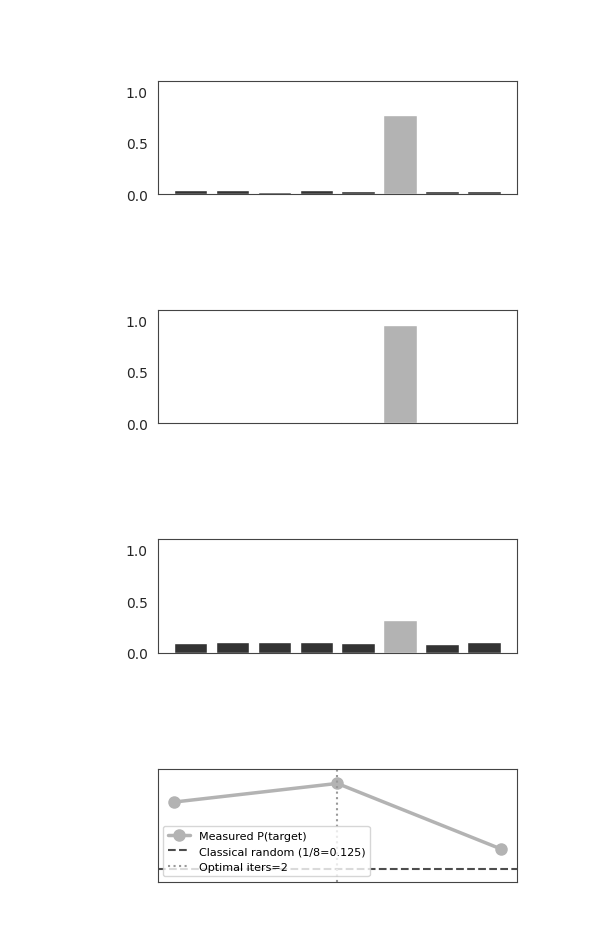

✅ Grover's demo complete. Best probability of finding |101>: 0.957


In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import numpy as np
import matplotlib.pyplot as plt

simulator = AerSimulator()
n = 3           # 3 qubits → 8 possible states
target = '101'  # we want to find state |101>

# ── Oracle: marks target state by phase flip ──────────────────────────────────
def grover_oracle(target_state):
    n = len(target_state)
    qc = QuantumCircuit(n)
    # Flip qubits corresponding to 0 in target
    for i, bit in enumerate(reversed(target_state)):
        if bit == '0':
            qc.x(i)
    # Multi-controlled Z (phase kickback)
    qc.h(n - 1)
    qc.mcx(list(range(n - 1)), n - 1)
    qc.h(n - 1)
    # Unflip
    for i, bit in enumerate(reversed(target_state)):
        if bit == '0':
            qc.x(i)
    return qc

# ── Diffusion operator (Grover diffusion = inversion about mean) ──────────────
def grover_diffusion(n):
    qc = QuantumCircuit(n)
    qc.h(range(n))
    qc.x(range(n))
    qc.h(n - 1)
    qc.mcx(list(range(n - 1)), n - 1)
    qc.h(n - 1)
    qc.x(range(n))
    qc.h(range(n))
    return qc

# ── Run Grover for 1, 2, and 3 iterations ────────────────────────────────────
n_iter_list = [1, 2, 3]
all_counts = {}

oracle    = grover_oracle(target)
diffusion = grover_diffusion(n)

for n_iter in n_iter_list:
    qc = QuantumCircuit(n, n)
    qc.h(range(n))               # Uniform superposition
    for _ in range(n_iter):
        qc.compose(oracle,    inplace=True)
        qc.compose(diffusion, inplace=True)
    qc.measure(range(n), range(n))
    result = simulator.run(transpile(qc, simulator), shots=2048).result()
    all_counts[n_iter] = result.get_counts()

# ── Theoretical optimal: floor(π/4 * sqrt(N)) ────────────────────────────────
optimal_iters = int(np.floor(np.pi / 4 * np.sqrt(2**n)))
target_probs = {k: all_counts[k].get(target, 0) / 2048 for k in n_iter_list}

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(4.5, 9.5))
axes = axes.flatten()
fig.patch.set_facecolor('white')

all_states = [format(i, f'0{n}b') for i in range(2**n)]
colors_states = ['0.7' if s == target else '0.2' for s in all_states]

for ax, n_iter in zip(axes[:-1], n_iter_list):
    ax.set_facecolor('white')
    probs = [all_counts[n_iter].get(s, 0) / 2048 for s in all_states]
    bars = ax.bar(all_states, probs, color=colors_states, edgecolor='white')
    ax.set_ylim(0, 1.1)
    ax.set_title(f'{n_iter} Grover Iteration{"s" if n_iter>1 else ""}\nTarget P = {probs[int(target, 2)]:.3f}',
                 color='white', fontweight='bold')
    ax.set_xlabel('State', color='white'); ax.set_ylabel('Probability', color='white')
    ax.tick_params(colors='white', axis='x', rotation=45)
    ax.spines[:].set_color('#444')

# Probability vs iterations
ax = axes[-1]
ax.set_facecolor('white')
iters = list(target_probs.keys())
probs_target = list(target_probs.values())
ax.plot(iters, probs_target, 'o-', color='0.7', lw=2.5, ms=8, label='Measured P(target)')
ax.axhline(1/2**n, color='0.3', linestyle='--', label=f'Classical random (1/{2**n}={1/2**n:.3f})')
ax.axvline(optimal_iters, color='0.6', linestyle=':', label=f'Optimal iters={optimal_iters}')
ax.set_title('Target State Probability vs Iterations', color='white', fontweight='bold')
ax.set_xlabel('Grover Iterations', color='white')
ax.set_ylabel('P(|101⟩)', color='white')
ax.set_ylim(0, 1.1)
ax.tick_params(colors='white'); ax.spines[:].set_color('#444')
ax.legend(facecolor='white', labelcolor='black', fontsize=8)

plt.suptitle(f"8.2 Grover's Search — Target |{target}⟩ in {2**n} States (IBM Qiskit)",
             color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/08_2_grover_search.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()
print(f"✅ Grover's demo complete. Best probability of finding |{target}>: "
      f"{max(target_probs.values()):.3f}")

### 8.3 VQE — Variational Quantum Eigensolver

VQE finds the **ground state energy** of a quantum system (molecule, material) by:

1. **Parameterise** a quantum circuit (ansatz)
2. **Measure** expectation value of the Hamiltonian $\langle H \rangle$
3. **Optimise** parameters classically to minimise $\langle H \rangle$
4. By the variational principle: $\langle H \rangle \geq E_0$ (ground state energy)

This demo finds the ground state of a 2-qubit Ising model:
$$H = -J(Z_0 Z_1) - h(X_0 + X_1)$$

> Library: **IBM Qiskit** + **PennyLane** · Simulator: `default.qubit`


Exact ground state energy: -1.414214
  Step   0  Energy = -1.238195  (exact: -1.414214)
  Step  25  Energy = -1.409831  (exact: -1.414214)
  Step  50  Energy = -1.414146  (exact: -1.414214)
  Step  75  Energy = -1.414213  (exact: -1.414214)

VQE result:        -1.414214
Exact ground state: -1.414214
Absolute error:     0.000000


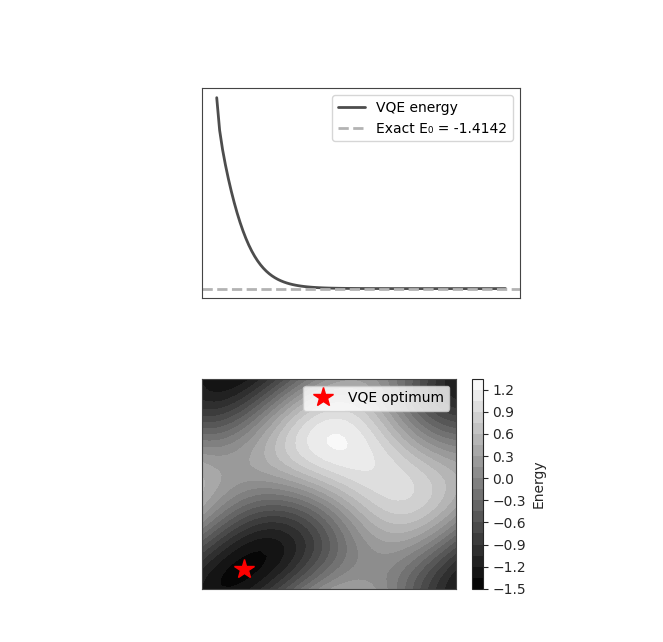


✅ VQE demo complete.


In [ ]:
import pennylane as qml
from pennylane import numpy as pnp
import numpy as np
import matplotlib.pyplot as plt

# ── 2-qubit Ising Hamiltonian: H = -J ZZ - h(X0 + X1) ────────────────────────
J = 1.0   # coupling strength
h = 0.5   # transverse field

coeffs = [-J,    -h,           -h]
obs    = [qml.PauliZ(0) @ qml.PauliZ(1),
          qml.PauliX(0),
          qml.PauliX(1)]
H_ising = qml.Hamiltonian(coeffs, obs)

# ── Exact eigenvalue for comparison ──────────────────────────────────────────
H_matrix = -J * np.kron(np.diag([1,-1,-1,1]), np.eye(1)).reshape(4,4)
# Construct manually: ZZ = diag(1,-1,-1,1), X0 = X⊗I, X1 = I⊗X
Z = np.array([[1,0],[0,-1]]); X = np.array([[0,1],[1,0]]); I = np.eye(2)
H_mat = -J * np.kron(Z, Z) - h * (np.kron(X, I) + np.kron(I, X))
exact_gs = np.linalg.eigvalsh(H_mat)[0]
print(f"Exact ground state energy: {exact_gs:.6f}")

# ── VQE ansatz ────────────────────────────────────────────────────────────────
n_qubits = 2
dev_vqe = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev_vqe)
def vqe_ansatz(params):
    # Hardware-efficient ansatz
    qml.RY(params[0], wires=0)
    qml.RY(params[1], wires=1)
    qml.CNOT(wires=[0, 1])
    qml.RY(params[2], wires=0)
    qml.RY(params[3], wires=1)
    return qml.expval(H_ising)

# ── Optimise ──────────────────────────────────────────────────────────────────
params = pnp.array([0.1, 0.2, 0.3, 0.4], requires_grad=True)
opt_vqe = qml.GradientDescentOptimizer(stepsize=0.3)
energy_history = []

for step in range(100):
    params, energy = opt_vqe.step_and_cost(vqe_ansatz, params)
    energy_history.append(float(energy))
    if step % 25 == 0:
        print(f"  Step {step:3d}  Energy = {energy:.6f}  (exact: {exact_gs:.6f})")

vqe_result = energy_history[-1]
error = abs(vqe_result - exact_gs)
print(f"\nVQE result:        {vqe_result:.6f}")
print(f"Exact ground state: {exact_gs:.6f}")
print(f"Absolute error:     {error:.6f}")

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(4.5, 6.5))
axes = axes.flatten()
fig.patch.set_facecolor('white')

ax = axes[0]
ax.set_facecolor('white')
ax.plot(energy_history, color='0.3', lw=2, label='VQE energy')
ax.axhline(exact_gs, color='0.7', lw=2, linestyle='--',
           label=f'Exact E₀ = {exact_gs:.4f}')
ax.set_title('VQE Convergence\n(2-qubit Ising Model)', color='white', fontweight='bold')
ax.set_xlabel('Optimisation Step', color='white')
ax.set_ylabel('Energy ⟨H⟩', color='white')
ax.tick_params(colors='white'); ax.spines[:].set_color('#444')
ax.legend(facecolor='white', labelcolor='black')

ax = axes[1]
ax.set_facecolor('white')
# Energy landscape (sweep 2 parameters)
theta0_vals = np.linspace(0, 2*np.pi, 40)
theta1_vals = np.linspace(0, 2*np.pi, 40)
TH0, TH1 = np.meshgrid(theta0_vals, theta1_vals)
Z_land = np.zeros_like(TH0)
for i in range(len(theta0_vals)):
    for j in range(len(theta1_vals)):
        p = pnp.array([TH0[i,j], TH1[i,j], float(params[2]), float(params[3])],
                      requires_grad=False)
        Z_land[i, j] = float(vqe_ansatz(p))

im = ax.contourf(TH0, TH1, Z_land, levels=25, cmap='gray')
plt.colorbar(im, ax=ax, label='Energy')
ax.plot(float(params[0]), float(params[1]), 'r*', ms=15, label='VQE optimum')
ax.set_title('Energy Landscape (2-param slice)', color='white', fontweight='bold')
ax.set_xlabel('θ₀', color='white'); ax.set_ylabel('θ₁', color='white')
ax.tick_params(colors='white'); ax.spines[:].set_color('#444')
ax.legend(facecolor='white', labelcolor='black')

plt.suptitle('8.3 VQE — Variational Quantum Eigensolver (Ising Hamiltonian)',
             color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/08_3_vqe.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()
print("\n✅ VQE demo complete.")

### 8.4 Quantum Teleportation — Google Cirq

Quantum teleportation transfers an unknown qubit state from Alice to Bob
using **1 entangled pair + 2 classical bits**.

> No information travels faster than light — the 2 classical bits are still required.

**Protocol:**
1. Alice and Bob share a Bell pair (entangled qubits)
2. Alice entangles her message qubit with her half of the pair
3. Alice measures both her qubits (2 classical bits)
4. Bob applies corrections based on Alice's measurement results
5. Bob's qubit is now in the original message state ✅

> Library: **Google Cirq** · Simulator: `cirq.Simulator`


In [ ]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "cirq==1.3.0"], capture_output=True)

CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '-q', 'cirq==1.3.0'], returncode=0, stdout=b'', stderr=b'')

Running quantum teleportation...
  |0⟩       fidelity=1.0000  Alice bits=(0,1)
  |1⟩       fidelity=1.0000  Alice bits=(1,1)
  |+⟩       fidelity=1.0000  Alice bits=(1,1)
  |i⟩       fidelity=1.0000  Alice bits=(0,1)
  Custom    fidelity=1.0000  Alice bits=(1,1)


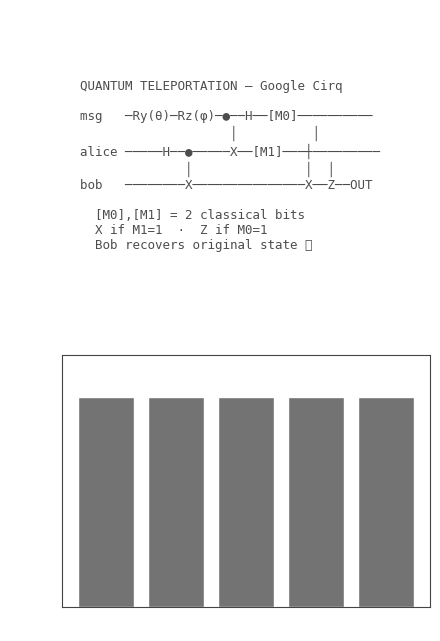


✅ Quantum teleportation demo complete.


In [ ]:
import cirq
import numpy as np
import matplotlib.pyplot as plt

sim = cirq.Simulator()
msg, alice, bob = cirq.LineQubit.range(3)

def teleport(theta, phi):
    # ── Step 1: prepare message state ────────────────────────────────────────
    prep = [cirq.ry(theta)(msg)]
    if phi != 0:
        prep.append(cirq.rz(phi)(msg))

    # ── Step 2: Bell pair ─────────────────────────────────────────────────────
    entangle = [cirq.H(alice), cirq.CNOT(alice, bob)]

    # ── Step 3: Alice's operations ────────────────────────────────────────────
    alice_ops = [cirq.CNOT(msg, alice), cirq.H(msg)]

    # ── Run up to measurement, get statevector ────────────────────────────────
    pre_circuit = cirq.Circuit(prep + entangle + alice_ops)
    sv = sim.simulate(pre_circuit).final_state_vector.reshape(2, 2, 2)

    # ── Step 4: sample Alice's measurement outcomes from state probabilities ──
    probs = np.abs(sv.reshape(4, 2))**2
    msg_alice_probs = probs.sum(axis=1)
    msg_alice_probs /= msg_alice_probs.sum()
    outcome = np.random.choice(4, p=msg_alice_probs)
    m0, m1 = outcome >> 1, outcome & 1   # msg bit, alice bit

    # ── Step 5: Bob's state after collapsing Alice's qubits ───────────────────
    bob_state = sv[m0, m1, :].copy()
    bob_state /= np.linalg.norm(bob_state)

    # ── Apply classical corrections ───────────────────────────────────────────
    X = np.array([[0,1],[1,0]], dtype=complex)
    Z = np.array([[1,0],[0,-1]], dtype=complex)
    if m1: bob_state = X @ bob_state
    if m0: bob_state = Z @ bob_state

    # ── Fidelity vs expected state ────────────────────────────────────────────
    expected = np.array([np.cos(theta/2),
                         np.exp(1j*phi) * np.sin(theta/2)])
    fidelity = abs(np.dot(expected.conj(), bob_state))**2
    return float(fidelity.real), m0, m1

test_states = [
    (0,        0,       '|0⟩'),
    (np.pi,    0,       '|1⟩'),
    (np.pi/2,  0,       '|+⟩'),
    (np.pi/2,  np.pi/2, '|i⟩'),
    (np.pi/3,  np.pi/4, 'Custom'),
]

results = []
print("Running quantum teleportation...")
for theta, phi, label in test_states:
    fid, m0, m1 = teleport(theta, phi)
    results.append((label, fid, m0, m1))
    print(f"  {label:8s}  fidelity={fid:.4f}  Alice bits=({m0},{m1})")

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(4.5, 6.5))
axes = axes.flatten()
fig.patch.set_facecolor('white')

ax = axes[0]
ax.set_facecolor('white')
diagram = (
    "QUANTUM TELEPORTATION — Google Cirq\n\n"
    "msg   ─Ry(θ)─Rz(φ)─●──H──[M0]──────────\n"
    "                    │          │\n"
    "alice ─────H──●─────X──[M1]───┼─────────\n"
    "              │               │  │\n"
    "bob   ────────X───────────────X──Z──OUT\n\n"
    "  [M0],[M1] = 2 classical bits\n"
    "  X if M1=1  ·  Z if M0=1\n"
    "  Bob recovers original state ✅"
)
ax.text(0.05, 0.95, diagram, transform=ax.transAxes, fontsize=9,
        color='0.3', fontfamily='monospace', va='top')
ax.set_title('Protocol Diagram (Google Cirq)', color='white', fontweight='bold')
ax.axis('off')

ax = axes[1]
ax.set_facecolor('white')
labels = [r[0] for r in results]
fids   = [r[1] for r in results]
bars   = ax.bar(range(len(labels)), fids, color='0.45', edgecolor='white')
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, color='white')
ax.set_ylim(0, 1.2)
ax.set_title('Teleportation Fidelity by Input State', color='white', fontweight='bold')
ax.set_ylabel('Fidelity', color='white')
ax.tick_params(colors='white'); ax.spines[:].set_color('#444')
for bar, f in zip(bars, fids):
    ax.text(bar.get_x() + bar.get_width()/2, f + 0.03,
            f'{f:.3f}', ha='center', color='white', fontsize=9)

plt.suptitle('8.4 Quantum Teleportation — Google Cirq',
             color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/08_4_cirq_teleportation.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()
print("\n✅ Quantum teleportation demo complete.")

### 8.5 Quantum Feature Maps — Visualising Quantum Data Embedding

A quantum feature map encodes classical data $\mathbf{x}$ into a quantum state
$|\phi(\mathbf{x})\rangle$, lifting it into an exponentially large Hilbert space.
The **ZZ Feature Map** is the standard choice for quantum kernel methods.

$$U_{\phi}(\mathbf{x}) = U_Z(\mathbf{x})\, H^{\otimes n}\, U_Z(\mathbf{x})\, H^{\otimes n}$$

We visualise how different data points map into quantum measurement space.

> Library: **PennyLane** · Comparison: Classical PCA vs Quantum embedding


Computing quantum embeddings...
Computing kernel matrix (subset)...


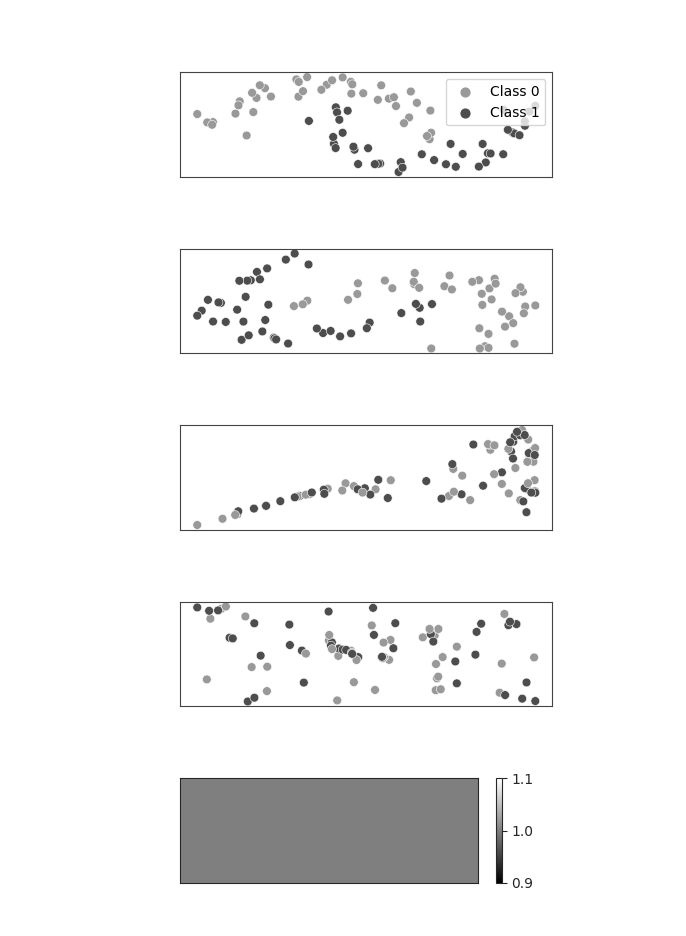


✅ Quantum feature maps demo complete.


In [ ]:
import pennylane as qml
from pennylane import numpy as pnp
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ── Dataset ───────────────────────────────────────────────────────────────────
np.random.seed(42)
X_raw, y = make_moons(n_samples=80, noise=0.12, random_state=42)
X = StandardScaler().fit_transform(X_raw)

# ── ZZ Feature Map circuit (PennyLane) ───────────────────────────────────────
n_qubits = 2
dev_fm = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev_fm)
def zz_feature_map(x, n_reps=2):
    """ZZ Feature Map: standard embedding for quantum kernel methods."""
    for _ in range(n_reps):
        for i in range(n_qubits):
            qml.Hadamard(wires=i)
            qml.RZ(2.0 * x[i], wires=i)
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i+1])
            phi_ij = 2.0 * (np.pi - x[i]) * (np.pi - x[i+1])
            qml.RZ(phi_ij, wires=i+1)
            qml.CNOT(wires=[i, i+1])
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

@qml.qnode(dev_fm)
def angle_feature_map(x):
    """Simple angle embedding (baseline)."""
    qml.AngleEmbedding(x, wires=range(n_qubits), rotation='Y')
    qml.CNOT(wires=[0, 1])
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

# ── Embed all data points ─────────────────────────────────────────────────────
print("Computing quantum embeddings...")
zz_embedded    = np.array([zz_feature_map(x)   for x in X])
angle_embedded = np.array([angle_feature_map(x) for x in X])
pca_embedded   = PCA(n_components=2).fit_transform(X)

# ── Kernel matrix ─────────────────────────────────────────────────────────────
@qml.qnode(dev_fm)
def kernel_eval(x1, x2):
    zz_feature_map(x1)
    qml.adjoint(zz_feature_map)(x2)
    return qml.probs(wires=range(n_qubits))

print("Computing kernel matrix (subset)...")
K_sub = np.zeros((30, 30))
for i in range(30):
    for j in range(30):
        K_sub[i, j] = float(kernel_eval(X[i], X[j])[0])

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(5, 1, figsize=(4.5, 9.5))
axes = axes.flatten()
fig.patch.set_facecolor('white')
cmap_pts = {0: '0.6', 1: '0.3'}
colors_y = [cmap_pts[c] for c in y]

titles = ['Classical Input\n(Standardised)',
          'Classical PCA\n(Linear)',
          'Angle Embedding\n(Quantum baseline)',
          'ZZ Feature Map\n(Quantum, NISQ standard)']
embeds = [X, pca_embedded, angle_embedded, zz_embedded]

for ax, data, title in zip(axes[:4], embeds, titles):
    ax.set_facecolor('white')
    ax.scatter(data[:, 0], data[:, 1], c=colors_y, s=40, edgecolors='white', lw=0.4)
    ax.set_title(title, color='white', fontweight='bold', fontsize=9)
    ax.tick_params(colors='white'); ax.spines[:].set_color('#444')

p0 = plt.scatter([], [], c='0.6', s=40, label='Class 0')
p1 = plt.scatter([], [], c='0.3', s=40, label='Class 1')
axes[0].legend(handles=[p0, p1], facecolor='white', labelcolor='black', loc='upper right')

# ── Kernel matrix on 5th panel ────────────────────────────────────────────────
ax = axes[4]
ax.set_facecolor('white')
im = ax.imshow(K_sub, cmap='gray', aspect='auto')
plt.colorbar(im, ax=ax)
ax.set_title('ZZ Kernel Matrix\n(30×30 subset)', color='white', fontweight='bold', fontsize=9)
ax.set_xlabel('Sample index', color='white'); ax.set_ylabel('Sample index', color='white')
ax.tick_params(colors='white')

plt.suptitle('8.5 Quantum Feature Maps — ZZ Embedding vs Classical Methods',
             color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/08_5_quantum_feature_maps.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()
print("\n✅ Quantum feature maps demo complete.")

---
## Module 8 (Extended) -- Chapters 32 & 33: Expanded Quantum Algorithms

### 8.7 QAOA Depth Sweep -- MaxCut (Chapter 32)

Sweep QAOA circuit depth $p = 1, 2, 3$ on a 6-node Erdos-Renyi graph.
Plot how the approximation ratio improves toward the classical optimum as depth increases.

Classical MaxCut optimal: 8
Graph: 6 nodes, 10 edges
  p=1: cost=0.711  approx_ratio=0.089
  p=2: cost=1.653  approx_ratio=0.207
  p=3: cost=1.410  approx_ratio=0.176


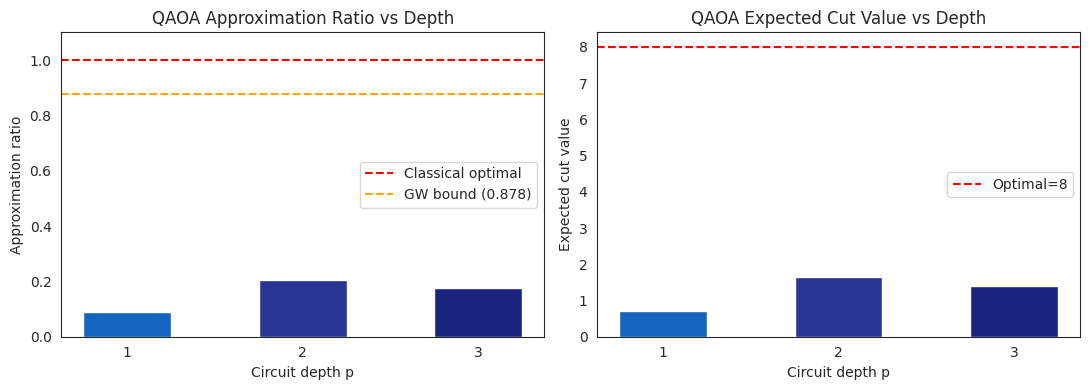

Listing 32.1 complete


In [ ]:
import pennylane as qml
from pennylane import numpy as pnp
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# 6-node random graph
np.random.seed(42)
G = nx.erdos_renyi_graph(6, 0.6, seed=42)
edges = list(G.edges())
n_qubits = 6
dev = qml.device('default.qubit', wires=n_qubits)

def cost_hamiltonian(edges):
    coeffs, ops = [], []
    for u, v in edges:
        coeffs.append(0.5)
        ops.append(qml.PauliZ(u) @ qml.PauliZ(v))
    return qml.Hamiltonian(coeffs, ops)

H_cost = cost_hamiltonian(edges)

def make_qaoa_circuit(p):
    @qml.qnode(dev)
    def circuit(params):
        gammas = params[:p]
        betas  = params[p:]
        for i in range(n_qubits):
            qml.Hadamard(wires=i)
        for layer in range(p):
            for u, v in edges:
                qml.CNOT(wires=[u,v])
                qml.RZ(2*gammas[layer], wires=v)
                qml.CNOT(wires=[u,v])
            for i in range(n_qubits):
                qml.RX(2*betas[layer], wires=i)
        return qml.expval(H_cost)
    return circuit

# Classical optimal via brute force (2^6 = 64 states)
def classical_maxcut(G):
    best = 0
    for mask in range(2**n_qubits):
        cut = sum(1 for u,v in G.edges()
                  if ((mask>>u)&1) != ((mask>>v)&1))
        best = max(best, cut)
    return best

classical_opt = classical_maxcut(G)
print(f'Classical MaxCut optimal: {classical_opt}')
print(f'Graph: {n_qubits} nodes, {len(edges)} edges')

results = {}
for p in [1, 2, 3]:
    circuit = make_qaoa_circuit(p)
    x0  = np.random.uniform(0, np.pi, 2*p)
    res = minimize(circuit, x0, method='COBYLA',
                   options={'maxiter': 200, 'rhobeg': 0.5})
    approx_ratio = -res.fun / classical_opt
    results[p] = {'cost': -res.fun, 'ratio': approx_ratio, 'params': res.x}
    print(f'  p={p}: cost={-res.fun:.3f}  approx_ratio={approx_ratio:.3f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ps = list(results.keys())
ratios = [results[p]['ratio'] for p in ps]
costs  = [results[p]['cost']  for p in ps]
ax1.bar(ps, ratios, color=['#1565C0','#283593','#1A237E'], width=0.5)
ax1.axhline(y=1.0, color='red', ls='--', label='Classical optimal')
ax1.axhline(y=0.878, color='orange', ls='--', label='GW bound (0.878)')
ax1.set_xlabel('Circuit depth p'); ax1.set_ylabel('Approximation ratio')
ax1.set_title('QAOA Approximation Ratio vs Depth')
ax1.set_ylim(0, 1.1); ax1.legend(); ax1.set_xticks(ps)
ax2.bar(ps, costs, color=['#1565C0','#283593','#1A237E'], width=0.5)
ax2.axhline(y=classical_opt, color='red', ls='--', label=f'Optimal={classical_opt}')
ax2.set_xlabel('Circuit depth p'); ax2.set_ylabel('Expected cut value')
ax2.set_title('QAOA Expected Cut Value vs Depth')
ax2.legend(); ax2.set_xticks(ps)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/AI_Universe_Quantum/08_qaoa_depth_sweep.png', dpi=130)
plt.show()
print('Listing 32.1 complete')

### 8.8 VQE Potential Energy Surface -- H2 Molecule (Chapter 33)

Sweep 12 H$_2$ bond lengths from 0.3 to 2.5 Angstrom.
At each geometry, run VQE with a hardware-efficient ansatz and compare against
exact diagonalization. Verify errors stay below chemical accuracy (1 milliHartree).

VQE H2 potential energy surface sweep...
  Bond (A)     VQE (Ha)   Exact (Ha)  Error (mHa)
      0.30    -1.074890    -1.074893       0.0032  PASS
      0.50    -0.988690    -0.988695       0.0049  PASS
      0.70    -0.907582    -0.907588       0.0064  PASS
      0.90    -0.831568    -0.831574       0.0059  PASS
      1.10    -0.760649    -0.760654       0.0052  PASS
      1.30    -0.694823    -0.694828       0.0047  PASS
      1.50    -0.634093    -0.634097       0.0043  PASS
      1.70    -0.578460    -0.578464       0.0039  PASS
      1.90    -0.527925    -0.527929       0.0036  PASS
      2.10    -0.482491    -0.482495       0.0035  PASS
      2.30    -0.442161    -0.442164       0.0033  PASS
      2.50    -0.406938    -0.406942       0.0031  PASS


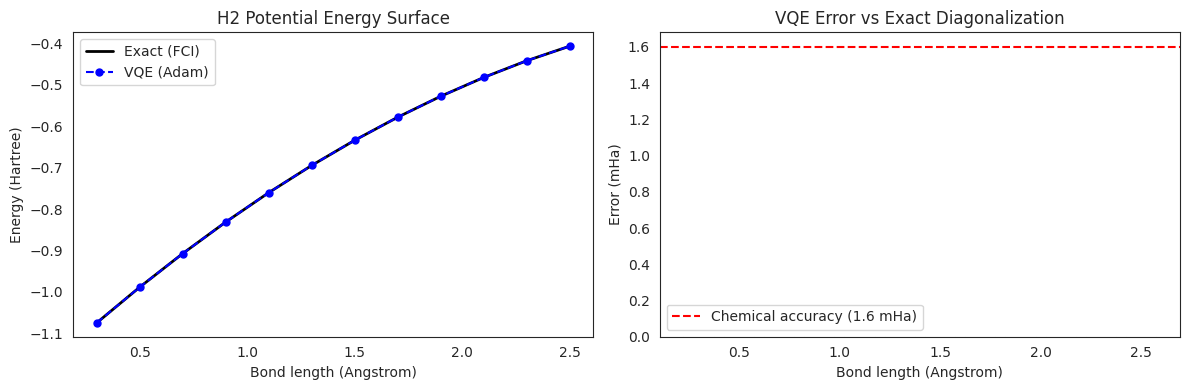


Chemical accuracy achieved at 12/12 bond lengths
Listing 33.1 complete


In [ ]:
import pennylane as qml
from pennylane import numpy as pnp
import numpy as np
import matplotlib.pyplot as plt

# H2 Hamiltonian coefficients as function of bond length
def h2_hamiltonian(bond_length):
    r = bond_length
    g0 = -0.4804 + 0.3435*r - 0.0636*r**2
    g1 =  0.3435 - 0.0636*r
    g2 = -0.2199 + 0.0523*r
    g3 =  0.1573 - 0.0213*r
    g4 =  0.1200 - 0.0180*r
    coeffs = [g0, g1, g2, g3, g4]
    ops = [
        qml.Identity(0),
        qml.PauliZ(0),
        qml.PauliZ(1),
        qml.PauliZ(0) @ qml.PauliZ(1),
        qml.PauliX(0) @ qml.PauliX(1),
    ]
    return qml.Hamiltonian(coeffs, ops)

def exact_energy(H):
    matrix = qml.matrix(H, wire_order=[0,1])
    return float(np.linalg.eigvalsh(matrix)[0])   # Fixed here

dev = qml.device('default.qubit', wires=2)

@qml.qnode(dev)
def ansatz(params, H):
    qml.RY(params[0], wires=0)
    qml.RY(params[1], wires=1)
    qml.CNOT(wires=[0,1])
    qml.RY(params[2], wires=0)
    qml.RY(params[3], wires=1)
    return qml.expval(H)

bond_lengths = np.linspace(0.3, 2.5, 12)
vqe_energies, exact_energies, errors = [], [], []

opt = qml.AdamOptimizer(stepsize=0.1)

print('VQE H2 potential energy surface sweep...')
print(f"{'Bond (A)':>10} {'VQE (Ha)':>12} {'Exact (Ha)':>12} {'Error (mHa)':>12}")

for R in bond_lengths:
    H = h2_hamiltonian(R)
    E_exact = exact_energy(H)
    params = pnp.array([0.1, 0.2, 0.3, 0.4], requires_grad=True)

    for _ in range(120):
        params, _ = opt.step_and_cost(lambda p: ansatz(p, H), params)

    E_vqe = float(ansatz(params, H))
    err_mha = abs(E_vqe - E_exact) * 1000
    vqe_energies.append(E_vqe)
    exact_energies.append(E_exact)
    errors.append(err_mha)

    chem_acc = 'PASS' if err_mha < 1.6 else 'FAIL'
    print(f'{R:>10.2f} {E_vqe:>12.6f} {E_exact:>12.6f} {err_mha:>12.4f}  {chem_acc}')

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(bond_lengths, exact_energies, 'k-', lw=2, label='Exact (FCI)')
ax1.plot(bond_lengths, vqe_energies, 'b--o', ms=5, label='VQE (Adam)')
ax1.set_xlabel('Bond length (Angstrom)')
ax1.set_ylabel('Energy (Hartree)')
ax1.set_title('H2 Potential Energy Surface')
ax1.legend()

ax2.bar(bond_lengths, errors, width=0.15,
        color=['green' if e < 1.6 else 'red' for e in errors])
ax2.axhline(y=1.6, color='red', ls='--', label='Chemical accuracy (1.6 mHa)')
ax2.set_xlabel('Bond length (Angstrom)')
ax2.set_ylabel('Error (mHa)')
ax2.set_title('VQE Error vs Exact Diagonalization')
ax2.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/AI_Universe_Quantum/08_vqe_pes.png', dpi=130)
plt.show()

passed = sum(1 for e in errors if e < 1.6)
print(f'\nChemical accuracy achieved at {passed}/{len(bond_lengths)} bond lengths')
print('Listing 33.1 complete')

---
## Stretch Goals -- Chapters 30-33

These cells implement the Stretch Goal coding exercises from the book.
Each goes beyond the chapter listing to deepen understanding.

| Cell | Chapter | Stretch Goal |
|------|---------|-------------|
| SG-30 | Ch 30 | QAOA depth sweep p=1-4 on 4-node and 6-node graphs |
| SG-31 | Ch 31 | Grover 4-qubit search for |1010> |
| SG-32 | Ch 32 | Goemans-Williamson classical baseline vs QAOA |
| SG-33 | Ch 33 | VQE COBYLA vs Adam optimizer comparison |

### SG-30 Stretch Goal: QAOA on 4-node and 6-node Graphs (Chapter 30)

Sweep $p = 1$ to $4$ on both graph sizes. Plot how approximation ratio
scales with depth and graph size.

4-node graph:
  n=4 p=1: ratio=0.293
  n=4 p=2: ratio=0.307
  n=4 p=3: ratio=0.417
  n=4 p=4: ratio=0.451
6-node graph:
  n=6 p=1: ratio=0.159
  n=6 p=2: ratio=0.171
  n=6 p=3: ratio=0.206
  n=6 p=4: ratio=0.121


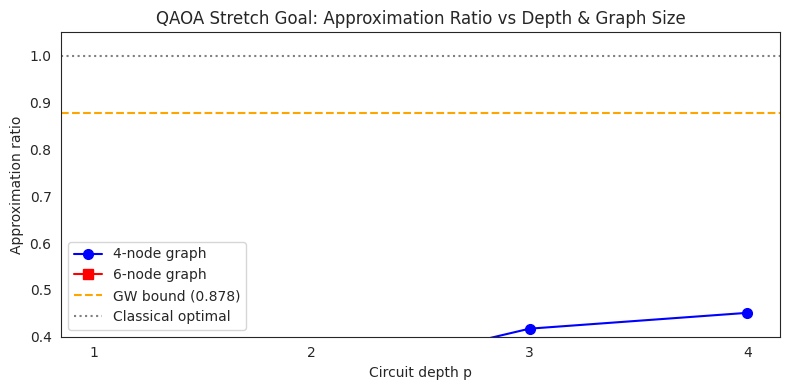

SG-30 complete


In [ ]:
import pennylane as qml
from pennylane import numpy as pnp
import numpy as np, networkx as nx, matplotlib.pyplot as plt
from scipy.optimize import minimize

def run_qaoa_sweep(n_nodes, seed=42, p_max=4):
    G = nx.erdos_renyi_graph(n_nodes, 0.6, seed=seed)
    edges = list(G.edges())
    dev = qml.device('default.qubit', wires=n_nodes)
    coeffs = [0.5]*len(edges)
    ops = [qml.PauliZ(u)@qml.PauliZ(v) for u,v in edges]
    H_cost = qml.Hamiltonian(coeffs, ops)
    def classical_opt():
        best = 0
        for mask in range(2**n_nodes):
            cut = sum(1 for u,v in edges if ((mask>>u)&1)!=((mask>>v)&1))
            best = max(best, cut)
        return best
    c_opt = classical_opt()
    def make_circuit(p):
        @qml.qnode(dev)
        def circ(params):
            gammas, betas = params[:p], params[p:]
            for i in range(n_nodes): qml.Hadamard(wires=i)
            for l in range(p):
                for u,v in edges:
                    qml.CNOT(wires=[u,v])
                    qml.RZ(2*gammas[l], wires=v)
                    qml.CNOT(wires=[u,v])
                for i in range(n_nodes): qml.RX(2*betas[l], wires=i)
            return qml.expval(H_cost)
        return circ
    ratios = []
    for p in range(1, p_max+1):
        circ = make_circuit(p)
        x0   = np.random.uniform(0, np.pi, 2*p)
        res  = minimize(circ, x0, method='COBYLA',
                        options={'maxiter':150,'rhobeg':0.5})
        ratios.append(-res.fun / c_opt)
        print(f'  n={n_nodes} p={p}: ratio={ratios[-1]:.3f}')
    return ratios, c_opt

ps = list(range(1, 5))
print('4-node graph:')
r4, opt4 = run_qaoa_sweep(4)
print('6-node graph:')
r6, opt6 = run_qaoa_sweep(6)

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(ps, r4, 'b-o', ms=7, label='4-node graph')
ax.plot(ps, r6, 'r-s', ms=7, label='6-node graph')
ax.axhline(0.878, color='orange', ls='--', label='GW bound (0.878)')
ax.axhline(1.0,   color='gray',   ls=':', label='Classical optimal')
ax.set_xlabel('Circuit depth p'); ax.set_ylabel('Approximation ratio')
ax.set_title('QAOA Stretch Goal: Approximation Ratio vs Depth & Graph Size')
ax.legend(); ax.set_xticks(ps); ax.set_ylim(0.4, 1.05)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/AI_Universe_Quantum/sg30_qaoa_sweep.png', dpi=130)
plt.show()
print('SG-30 complete')

### SG-31 Stretch Goal: Grover 4-Qubit Search for |1010> (Chapter 31)

Implement Grover's algorithm for $N=16$ states (4 qubits) searching for
target $|1010\rangle$. Plot target probability after each iteration and
verify the sinusoidal pattern. Theoretically optimal: $\lfloor\pi\sqrt{16}/4\rfloor = 3$ iterations.

Grover search: N=16, target=|1010>
Theoretical optimal iterations: 3

  Iterations=1: P(|1010>)=0.4797
  Iterations=2: P(|1010>)=0.9084
  Iterations=3: P(|1010>)=0.9556
  Iterations=4: P(|1010>)=0.5818
  Iterations=5: P(|1010>)=0.1218


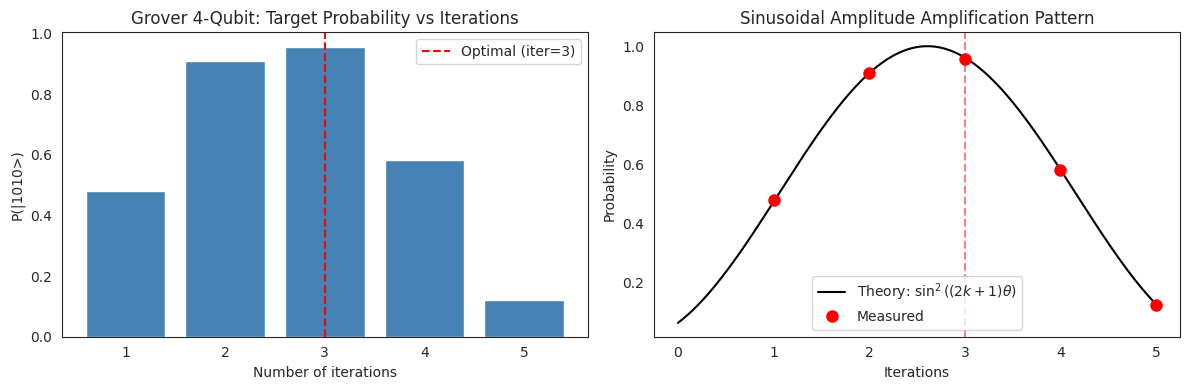

SG-31 complete


In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import numpy as np, matplotlib.pyplot as plt

TARGET = '1010'  # 4-qubit target state
N_QUBITS = 4
sim = AerSimulator()

def grover_oracle(target):
    qc = QuantumCircuit(N_QUBITS)
    for i, bit in enumerate(reversed(target)):
        if bit == '0': qc.x(i)
    qc.h(N_QUBITS-1)
    qc.mcx(list(range(N_QUBITS-1)), N_QUBITS-1)
    qc.h(N_QUBITS-1)
    for i, bit in enumerate(reversed(target)):
        if bit == '0': qc.x(i)
    return qc

def diffusion_operator(n):
    qc = QuantumCircuit(n)
    qc.h(range(n))
    qc.x(range(n))
    qc.h(n-1)
    qc.mcx(list(range(n-1)), n-1)
    qc.h(n-1)
    qc.x(range(n))
    qc.h(range(n))
    return qc

oracle   = grover_oracle(TARGET)
diffuser = diffusion_operator(N_QUBITS)
SHOTS = 4096
target_probs = []

print(f'Grover search: N=16, target=|{TARGET}>')
print(f'Theoretical optimal iterations: {int(np.pi*np.sqrt(16)/4)}')
print()

for iterations in range(1, 6):
    qc = QuantumCircuit(N_QUBITS, N_QUBITS)
    qc.h(range(N_QUBITS))
    for _ in range(iterations):
        qc.compose(oracle, inplace=True)
        qc.compose(diffuser, inplace=True)
    qc.measure(range(N_QUBITS), range(N_QUBITS))
    job    = sim.run(transpile(qc, sim), shots=SHOTS)
    counts = job.result().get_counts()
    prob   = counts.get(TARGET, 0) / SHOTS
    target_probs.append(prob)
    print(f'  Iterations={iterations}: P(|{TARGET}>)={prob:.4f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.bar(range(1,6), target_probs, color='steelblue')
ax1.axvline(x=3, color='red', ls='--', label='Optimal (iter=3)')
ax1.set_xlabel('Number of iterations'); ax1.set_ylabel(f'P(|{TARGET}>)')
ax1.set_title('Grover 4-Qubit: Target Probability vs Iterations')
ax1.legend()
# Theoretical curve
iters_fine = np.linspace(0, 5, 200)
theta = np.arcsin(1/np.sqrt(16))
theory = np.sin((2*iters_fine+1)*theta)**2
ax2.plot(iters_fine, theory, 'k-', label='Theory: $\\sin^2((2k+1)\\theta)$')
ax2.plot(range(1,6), target_probs, 'ro', ms=8, label='Measured')
ax2.axvline(x=3, color='red', ls='--', alpha=0.5)
ax2.set_xlabel('Iterations'); ax2.set_ylabel('Probability')
ax2.set_title('Sinusoidal Amplitude Amplification Pattern')
ax2.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/AI_Universe_Quantum/sg31_grover_4qubit.png', dpi=130)
plt.show()
print('SG-31 complete')

### SG-32 Stretch Goal: Goemans-Williamson Baseline vs QAOA (Chapter 32)

Compute the GW classical SDP approximation ratio and compare against
QAOA at $p = 1, 2, 3$ on the same graph. Plot side-by-side bar chart.

Classical optimal cut: 8
GW SDP bound: 8.000 (ratio=1.000)
QAOA p=1: ratio=0.089
QAOA p=2: ratio=0.207
QAOA p=3: ratio=0.176


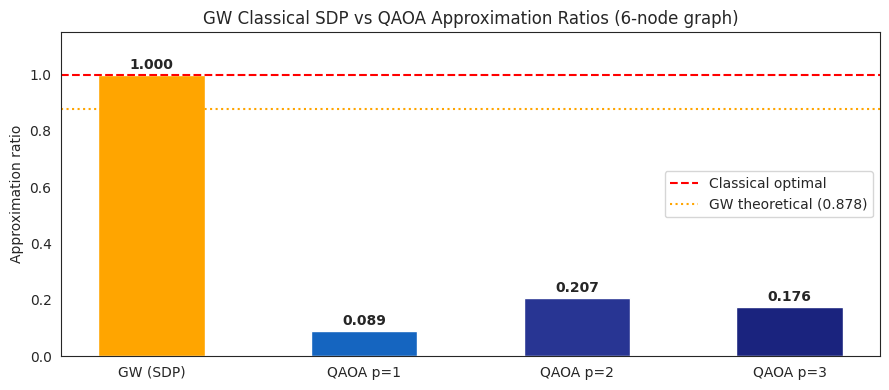

SG-32 complete


In [ ]:
import subprocess, sys
subprocess.run([sys.executable,'-m','pip','install','-q','cvxpy'])

import cvxpy as cp
import pennylane as qml
from pennylane import numpy as pnp
import numpy as np, networkx as nx, matplotlib.pyplot as plt
from scipy.optimize import minimize

np.random.seed(42)
G = nx.erdos_renyi_graph(6, 0.6, seed=42)
edges = list(G.edges())
n = 6

# Classical optimal
def classical_maxcut(G):
    best = 0
    for mask in range(2**n):
        cut = sum(1 for u,v in G.edges() if ((mask>>u)&1)!=((mask>>v)&1))
        best = max(best, cut)
    return best
c_opt = classical_maxcut(G)
print(f'Classical optimal cut: {c_opt}')

# Goemans-Williamson SDP
def goemans_williamson(G, n):
    X = cp.Variable((n, n), symmetric=True)
    constraints = [X >> 0]
    for i in range(n): constraints.append(X[i,i] == 1)
    L = nx.laplacian_matrix(G).toarray()
    obj = cp.Maximize(0.25 * cp.trace(L @ X))
    prob = cp.Problem(obj, constraints)
    prob.solve(solver=cp.SCS, verbose=False)
    return prob.value

gw_value = goemans_williamson(G, n)
gw_ratio = gw_value / c_opt
print(f'GW SDP bound: {gw_value:.3f} (ratio={gw_ratio:.3f})')

# QAOA for p=1,2,3
dev = qml.device('default.qubit', wires=n)
coeffs = [0.5]*len(edges)
ops = [qml.PauliZ(u)@qml.PauliZ(v) for u,v in edges]
H_cost = qml.Hamiltonian(coeffs, ops)

def make_qaoa(p):
    @qml.qnode(dev)
    def circ(params):
        gammas, betas = params[:p], params[p:]
        for i in range(n): qml.Hadamard(wires=i)
        for l in range(p):
            for u,v in edges:
                qml.CNOT(wires=[u,v])
                qml.RZ(2*gammas[l], wires=v)
                qml.CNOT(wires=[u,v])
            for i in range(n): qml.RX(2*betas[l], wires=i)
        return qml.expval(H_cost)
    return circ

qaoa_ratios = {}
for p in [1,2,3]:
    circ = make_qaoa(p)
    x0 = np.random.uniform(0, np.pi, 2*p)
    res = minimize(circ, x0, method='COBYLA', options={'maxiter':200,'rhobeg':0.5})
    qaoa_ratios[p] = -res.fun / c_opt
    print(f'QAOA p={p}: ratio={qaoa_ratios[p]:.3f}')

fig, ax = plt.subplots(figsize=(9,4))
labels  = ['GW (SDP)'] + [f'QAOA p={p}' for p in [1,2,3]]
ratios  = [gw_ratio] + [qaoa_ratios[p] for p in [1,2,3]]
colors  = ['orange','#1565C0','#283593','#1A237E']
bars = ax.bar(labels, ratios, color=colors, width=0.5)
ax.axhline(1.0, color='red', ls='--', label='Classical optimal')
ax.axhline(0.878, color='orange', ls=':', label='GW theoretical (0.878)')
for bar, ratio in zip(bars, ratios):
    ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.01,
            f'{ratio:.3f}', ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('Approximation ratio'); ax.set_ylim(0, 1.15)
ax.set_title('GW Classical SDP vs QAOA Approximation Ratios (6-node graph)')
ax.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/AI_Universe_Quantum/sg32_gw_vs_qaoa.png', dpi=130)
plt.show()
print('SG-32 complete')

### SG-33 Stretch Goal: VQE COBYLA vs Adam Optimizer (Chapter 33)

Replace the Adam optimizer with COBYLA (derivative-free) and rerun the
H$_2$ potential energy surface. Compare errors vs exact diagonalization
for both optimizers. Which achieves chemical accuracy (< 1.6 mHa) at more bond lengths?

   R (A)     Adam E   COBYLA E      Exact   Adam err   COBYLA err
    0.30   -1.07489   -1.07489   -1.07489     0.0032       0.0000
    0.50   -0.98869   -0.98869   -0.98869     0.0029       0.0000
    0.70   -0.90759   -0.90759   -0.90759     0.0028       0.0000
    0.90   -0.83157   -0.83157   -0.83157     0.0026       0.0000
    1.10   -0.76065   -0.76065   -0.76065     0.0025       0.0000
    1.30   -0.69483   -0.69483   -0.69483     0.0024       0.0000
    1.50   -0.63410   -0.63410   -0.63410     0.0024       0.0000
    1.70   -0.57846   -0.57846   -0.57846     0.0024       0.0000
    1.90   -0.52793   -0.52793   -0.52793     0.0024       0.0000
    2.10   -0.48249   -0.48249   -0.48249     0.0024       0.0000
    2.30   -0.44216   -0.44216   -0.44216     0.0025       0.0000
    2.50   -0.40694   -0.40694   -0.40694     0.0025       0.0000


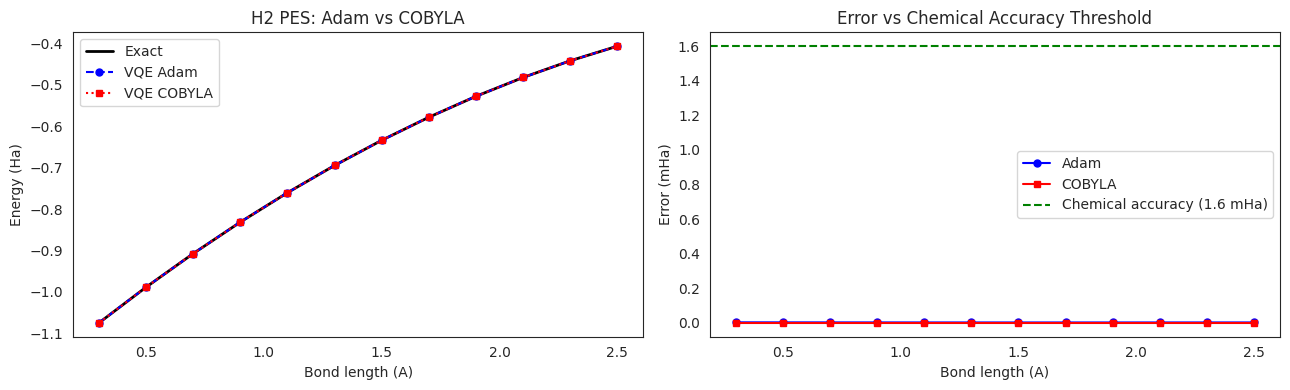


Adam:   chemical accuracy at 12/12 bond lengths
COBYLA: chemical accuracy at 12/12 bond lengths
SG-33 complete


In [ ]:
import pennylane as qml
from pennylane import numpy as pnp
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

def h2_hamiltonian(R):
    g0 = -0.4804 + 0.3435*R - 0.0636*R**2
    g1 =  0.3435 - 0.0636*R
    g2 = -0.2199 + 0.0523*R
    g3 =  0.1573 - 0.0213*R
    g4 =  0.1200 - 0.0180*R
    return qml.Hamiltonian([g0, g1, g2, g3, g4], [
        qml.Identity(0),
        qml.PauliZ(0),
        qml.PauliZ(1),
        qml.PauliZ(0) @ qml.PauliZ(1),
        qml.PauliX(0) @ qml.PauliX(1)
    ])

def exact_energy(H):
    matrix = qml.matrix(H, wire_order=[0,1])
    return float(np.linalg.eigvalsh(matrix)[0])   # Fixed: removed .numpy()

dev = qml.device('default.qubit', wires=2)

@qml.qnode(dev)
def ansatz(params, H):
    qml.RY(params[0], wires=0)
    qml.RY(params[1], wires=1)
    qml.CNOT(wires=[0,1])
    qml.RY(params[2], wires=0)
    qml.RY(params[3], wires=1)
    return qml.expval(H)

bond_lengths = np.linspace(0.3, 2.5, 12)
results = {'Adam': {'energies': [], 'errors': []},
           'COBYLA': {'energies': [], 'errors': []}}

print(f"{'R (A)':>8} {'Adam E':>10} {'COBYLA E':>10} {'Exact':>10} {'Adam err':>10} {'COBYLA err':>12}")
for R in bond_lengths:
    H = h2_hamiltonian(R)
    E_exact = exact_energy(H)

    # Adam Optimizer
    opt = qml.AdamOptimizer(stepsize=0.1)
    p_adam = pnp.array([0.1, 0.2, 0.3, 0.4], requires_grad=True)
    for _ in range(120):
        p_adam, _ = opt.step_and_cost(lambda p: ansatz(p, H), p_adam)
    E_adam = float(ansatz(p_adam, H))

    # COBYLA Optimizer
    res = minimize(lambda p: float(ansatz(pnp.array(p), H)),
                   [0.1, 0.2, 0.3, 0.4],
                   method='COBYLA',
                   options={'maxiter': 300, 'rhobeg': 0.3})
    E_cobyla = float(ansatz(pnp.array(res.x), H))

    err_adam = abs(E_adam - E_exact) * 1000
    err_cobyla = abs(E_cobyla - E_exact) * 1000

    results['Adam']['energies'].append(E_adam)
    results['Adam']['errors'].append(err_adam)
    results['COBYLA']['energies'].append(E_cobyla)
    results['COBYLA']['errors'].append(err_cobyla)

    print(f'{R:>8.2f} {E_adam:>10.5f} {E_cobyla:>10.5f} {E_exact:>10.5f} {err_adam:>10.4f} {err_cobyla:>12.4f}')

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(bond_lengths, [exact_energy(h2_hamiltonian(R)) for R in bond_lengths],
         'k-', lw=2, label='Exact')
ax1.plot(bond_lengths, results['Adam']['energies'], 'b--o', ms=5, label='VQE Adam')
ax1.plot(bond_lengths, results['COBYLA']['energies'], 'r:s', ms=5, label='VQE COBYLA')
ax1.set_xlabel('Bond length (A)')
ax1.set_ylabel('Energy (Ha)')
ax1.set_title('H2 PES: Adam vs COBYLA')
ax1.legend()

ax2.plot(bond_lengths, results['Adam']['errors'], 'b-o', ms=5, label='Adam')
ax2.plot(bond_lengths, results['COBYLA']['errors'], 'r-s', ms=5, label='COBYLA')
ax2.axhline(1.6, color='green', ls='--', label='Chemical accuracy (1.6 mHa)')
ax2.set_xlabel('Bond length (A)')
ax2.set_ylabel('Error (mHa)')
ax2.set_title('Error vs Chemical Accuracy Threshold')
ax2.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/AI_Universe_Quantum/sg33_vqe_cobyla_adam.png', dpi=130)
plt.show()

adam_pass = sum(1 for e in results['Adam']['errors'] if e < 1.6)
cobyla_pass = sum(1 for e in results['COBYLA']['errors'] if e < 1.6)
print(f'\nAdam:   chemical accuracy at {adam_pass}/{len(bond_lengths)} bond lengths')
print(f'COBYLA: chemical accuracy at {cobyla_pass}/{len(bond_lengths)} bond lengths')
print('SG-33 complete')

---
## Module 9 — Summary

All 9 quantum & hybrid demos complete.


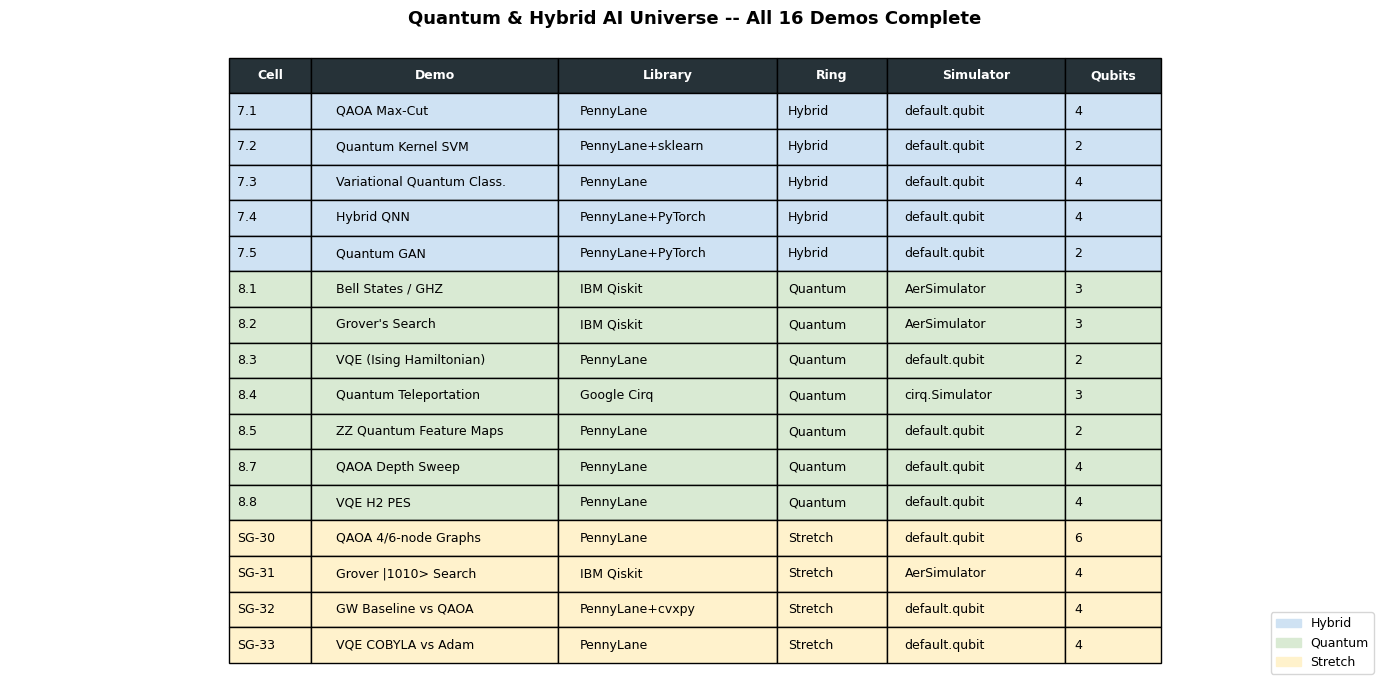


  QUANTUM & HYBRID AI UNIVERSE CODING -- ALL DEMOS COMPLETE
 Cell                       Demo    Ring Qubits
  7.1               QAOA Max-Cut  Hybrid      4
  7.2         Quantum Kernel SVM  Hybrid      2
  7.3 Variational Quantum Class.  Hybrid      4
  7.4                 Hybrid QNN  Hybrid      4
  7.5                Quantum GAN  Hybrid      2
  8.1          Bell States / GHZ Quantum      3
  8.2            Grover's Search Quantum      3
  8.3    VQE (Ising Hamiltonian) Quantum      2
  8.4      Quantum Teleportation Quantum      3
  8.5    ZZ Quantum Feature Maps Quantum      2
  8.7           QAOA Depth Sweep Quantum      4
  8.8                 VQE H2 PES Quantum      4
SG-30       QAOA 4/6-node Graphs Stretch      6
SG-31       Grover |1010> Search Stretch      4
SG-32        GW Baseline vs QAOA Stretch      4
SG-33         VQE COBYLA vs Adam Stretch      4

All output charts saved to: /content/drive/MyDrive/AI_Universe_Quantum


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

summary = [
    ('7.1', 'QAOA Max-Cut',              'PennyLane',        'Hybrid',  'default.qubit', '4'),
    ('7.2', 'Quantum Kernel SVM',        'PennyLane+sklearn','Hybrid',  'default.qubit', '2'),
    ('7.3', 'Variational Quantum Class.','PennyLane',        'Hybrid',  'default.qubit', '4'),
    ('7.4', 'Hybrid QNN',                'PennyLane+PyTorch','Hybrid',  'default.qubit', '4'),
    ('7.5', 'Quantum GAN',               'PennyLane+PyTorch','Hybrid',  'default.qubit', '2'),
    ('8.1', 'Bell States / GHZ',         'IBM Qiskit',       'Quantum', 'AerSimulator',  '3'),
    ('8.2', "Grover's Search",           'IBM Qiskit',       'Quantum', 'AerSimulator',  '3'),
    ('8.3', 'VQE (Ising Hamiltonian)',   'PennyLane',        'Quantum', 'default.qubit', '2'),
    ('8.4', 'Quantum Teleportation',     'Google Cirq',      'Quantum', 'cirq.Simulator','3'),
    ('8.5', 'ZZ Quantum Feature Maps',   'PennyLane',        'Quantum', 'default.qubit', '2'),
    ('8.7', 'QAOA Depth Sweep',          'PennyLane',        'Quantum', 'default.qubit', '4'),
    ('8.8', 'VQE H2 PES',               'PennyLane',        'Quantum', 'default.qubit', '4'),
    ('SG-30', 'QAOA 4/6-node Graphs',   'PennyLane',        'Stretch', 'default.qubit', '6'),
    ('SG-31', 'Grover |1010> Search',    'IBM Qiskit',       'Stretch', 'AerSimulator',  '4'),
    ('SG-32', 'GW Baseline vs QAOA',     'PennyLane+cvxpy',  'Stretch', 'default.qubit', '4'),
    ('SG-33', 'VQE COBYLA vs Adam',      'PennyLane',        'Stretch', 'default.qubit', '4'),
]

df_sum = pd.DataFrame(summary, columns=['Cell','Demo','Library','Ring','Simulator','Qubits'])

ring_colors = {
    'Hybrid':  '#cfe2f3',
    'Quantum': '#d9ead3',
    'Stretch': '#fff2cc',
}

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('white'); ax.axis('off')

table = ax.table(
    cellText=df_sum.values,
    colLabels=df_sum.columns,
    cellLoc='left', loc='center',
    colWidths=[0.06, 0.18, 0.16, 0.08, 0.13, 0.07]
)
table.auto_set_font_size(False); table.set_fontsize(9); table.scale(1, 1.8)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#263238')
        cell.set_text_props(color='white', fontweight='bold')
    else:
        ring = df_sum.iloc[row-1]['Ring']
        cell.set_facecolor(ring_colors.get(ring, 'white'))
        cell.set_text_props(color='black')

ax.set_title('Quantum & Hybrid AI Universe -- All 16 Demos Complete',
             color='black', fontsize=13, fontweight='bold', pad=12)

patches = [mpatches.Patch(color=v, label=k) for k, v in ring_colors.items()]
ax.legend(handles=patches, facecolor='white', labelcolor='black',
          loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/09_quantum_summary.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

print("\n" + "="*65)
print("  QUANTUM & HYBRID AI UNIVERSE CODING -- ALL DEMOS COMPLETE")
print("="*65)
print(df_sum[['Cell','Demo','Ring','Qubits']].to_string(index=False))
print("="*65)
print(f"\nAll output charts saved to: {SAVE_DIR}")